Project root : /home/b/bl/bluetopazzz
Artifact dir : /home/b/bl/bluetopazzz/artifacts_500m_kb


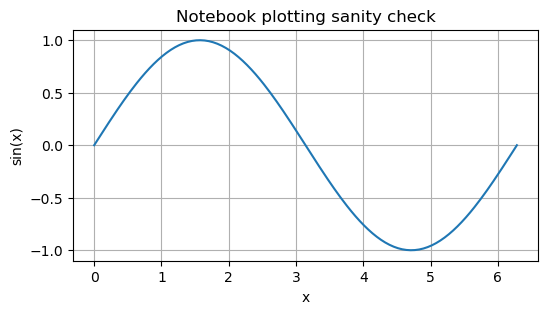

In [1]:
# ============================================================
# CELL 1: NOTEBOOK SETUP
# ============================================================
# This cell prepares the notebook runtime and establishes a
# consistent environment for the rest of the experiment.
#
# Responsibilities:
# 1. Import core libraries
# 2. Configure plotting defaults
# 3. Set random seeds
# 4. Create reusable dependency-check helpers
# 5. Define project directories used throughout the notebook
# 6. Define small JSON / hashing helpers used across phases
# ============================================================

%matplotlib inline

import os
import io
import gc
import re
import json
import math
import time
import shlex
import random
import select
import signal
import shutil
import textwrap
import hashlib
import subprocess
from collections import Counter
from pathlib import Path
from dataclasses import dataclass, asdict

import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from IPython.display import clear_output, display

import torch
import torch.nn as nn
import torch.nn.functional as F

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ------------------------------------------------------------
# Plot defaults
# ------------------------------------------------------------
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

# ------------------------------------------------------------
# Project directories
# ------------------------------------------------------------
PROJECT_ROOT = Path.cwd()
ARTIFACT_DIR = PROJECT_ROOT / "artifacts_500m_kb"

TOKENIZER_DIR = ARTIFACT_DIR / "tokenizer"
DATA_DIR = ARTIFACT_DIR / "data"
RUNS_DIR = ARTIFACT_DIR / "runs"
MODULE_DIR = ARTIFACT_DIR / "modules"

CORPUS_DIR = DATA_DIR / "corpus"
PHASE_DATA_DIR = DATA_DIR / "phase_data"
EVAL_DIR = ARTIFACT_DIR / "eval"

for d in [ARTIFACT_DIR, TOKENIZER_DIR, DATA_DIR, RUNS_DIR, MODULE_DIR, CORPUS_DIR, PHASE_DATA_DIR, EVAL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Project root :", PROJECT_ROOT)
print("Artifact dir :", ARTIFACT_DIR)

# ------------------------------------------------------------
# Dependency guards
# ------------------------------------------------------------
def require_globals(*names):
    missing = [name for name in names if name not in globals()]
    if missing:
        raise RuntimeError(
            "Missing required notebook objects. Rerun earlier cells first:\n"
            + "\n".join(f"- {m}" for m in missing)
        )

def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)

def load_json(path, default=None):
    path = Path(path)
    if not path.exists():
        return default
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def stable_text_hash(text: str) -> str:
    return hashlib.sha1(text.encode("utf-8")).hexdigest()

def show_sanity_plot():
    x = np.linspace(0, 2 * np.pi, 200)
    y = np.sin(x)

    plt.figure(figsize=(6, 3))
    plt.plot(x, y)
    plt.title("Notebook plotting sanity check")
    plt.xlabel("x")
    plt.ylabel("sin(x)")
    plt.show()

show_sanity_plot()

In [2]:
# ============================================================
# CELL 2: DATASET + TOKENIZER BACKEND SETUP
# ============================================================
# This cell ensures the libraries for:
# 1. subword tokenization
# 2. Hugging Face dataset streaming
# are available.
#
# We use:
# - sentencepiece for tokenizer training
# - datasets for loading OpenWebText / FineWeb-like corpora
#
# Why this matters:
# - Your pasted docs alone are too small for a 500M-class model
# - We need a larger background corpus
# ============================================================

try:
    import sentencepiece as spm
    print("SentencePiece is already installed.")
except ImportError:
    print("Installing sentencepiece...")
    !pip -q install sentencepiece
    import sentencepiece as spm
    print("SentencePiece installed successfully.")

try:
    import datasets
    from datasets import load_dataset
    print("datasets is already installed.")
except ImportError:
    print("Installing datasets...")
    !pip -q install datasets
    import datasets
    from datasets import load_dataset
    print("datasets installed successfully.")

print("sentencepiece module:", spm.__file__)
print("datasets version:", datasets.__version__)

SentencePiece is already installed.


/home/b/bl/bluetopazzz/mamba/envs/torch-gpu/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


datasets is already installed.
sentencepiece module: /home/b/bl/bluetopazzz/mamba/envs/torch-gpu/lib/python3.11/site-packages/sentencepiece/__init__.py
datasets version: 4.8.4


torch.cuda.is_available(): True
Visible GPU count: 3
GPU 0: NVIDIA RTX A6000 | free=47.12 GiB | total=47.40 GiB
GPU 1: NVIDIA RTX A6000 | free=32.95 GiB | total=47.40 GiB
GPU 2: NVIDIA RTX A6000 | free=46.87 GiB | total=47.40 GiB
bf16 supported: True

This notebook will still proceed, but the weakest rank will set the memory ceiling.


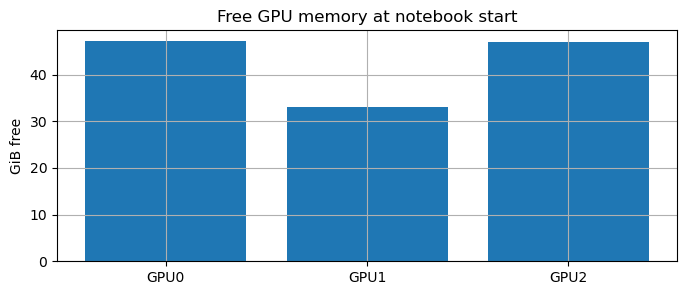

In [3]:
# ============================================================
# CELL 3: GPU / ENVIRONMENT PREFLIGHT
# ============================================================
# This cell checks whether the runtime environment is suitable
# for the planned 3-GPU training run.
#
# Responsibilities:
# 1. Confirm PyTorch can see CUDA GPUs
# 2. Report free memory per visible GPU
# 3. Confirm bf16 support
# 4. Confirm this notebook can see the intended 3 GPUs
# 5. Warn if one GPU is significantly weaker than the others
#
# Important:
# This does not start training. It only checks whether the
# hardware environment looks sane enough to proceed.
# ============================================================

cuda_ok = torch.cuda.is_available()
print("torch.cuda.is_available():", cuda_ok)

if not cuda_ok:
    raise RuntimeError("CUDA is not available. This notebook expects GPU training.")

gpu_count = torch.cuda.device_count()
print("Visible GPU count:", gpu_count)

for i in range(gpu_count):
    free_bytes, total_bytes = torch.cuda.mem_get_info(i)
    print(
        f"GPU {i}: {torch.cuda.get_device_name(i)} | "
        f"free={free_bytes/1024**3:.2f} GiB | total={total_bytes/1024**3:.2f} GiB"
    )

bf16_supported = torch.cuda.is_bf16_supported()
print("bf16 supported:", bf16_supported)

if gpu_count < 3:
    raise RuntimeError(
        "This notebook is configured for 3-GPU training. Fewer than 3 visible GPUs were found."
    )

# Soft warning if GPU memory is asymmetric
free_gib = [torch.cuda.mem_get_info(i)[0] / 1024**3 for i in range(gpu_count)]
min_free = min(free_gib[:3])
max_free = max(free_gib[:3])

if max_free - min_free > 8:
    print(
        "\nWARNING: The visible GPUs have noticeably asymmetric free memory.\n"
        "This notebook will still proceed, but the weakest rank will set the memory ceiling."
    )

# Lightweight visual summary
plt.figure(figsize=(8, 3))
plt.bar([f"GPU{i}" for i in range(gpu_count)], free_gib)
plt.title("Free GPU memory at notebook start")
plt.ylabel("GiB free")
plt.show()

Number of local documents loaded: 3
Web corpus choice: fineweb_edu
Tokenizer max streamed docs: 60000
Training max streamed docs : 80000
Tokenizer vocab size       : 16000
Active training phase      : base


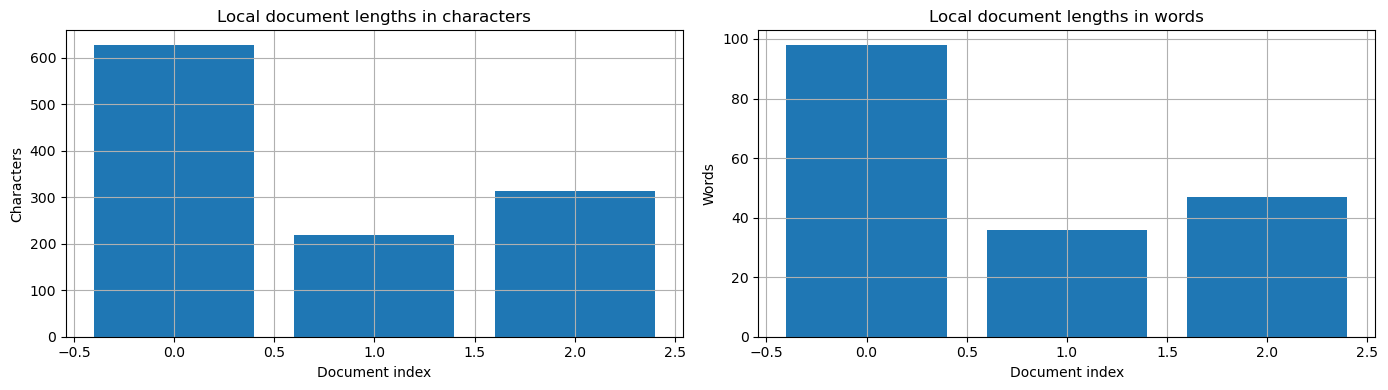


Preview of first local document:

## A Reimagined World: The Untraveled Path of Africa and the Arab Peninsula

### Introduction

The last few centuries have witnessed the world evolving at an unprecedented rate, largely influenced by Western hegemony. But history, as we know, is often a consequence of a few pivotal decisions and events. It's crucial to reevaluate these decisions, scrutinize our current trajectories, and reimagine alternative paths that might have led to more equitable outcomes. This report dives into the intricacies of a world where Africa, with its historical connections to the Arab Peninsula, took a more central role in global affairs.


In [4]:
# ============================================================
# CELL 4: RAW DOCUMENT STORE + CORPUS / PHASE CONFIG
# ============================================================
# This cell defines:
# 1. local curated documents
# 2. the web corpus source
# 3. tokenizer-training mixture
# 4. base-pretraining mixture
# 5. domain-adaptation mixture
#
# Core design change:
# - We no longer treat all training as one undifferentiated run.
# - We explicitly separate:
#     PHASE A = broad base language modeling
#     PHASE B = domain adaptation / shaping
# ============================================================

RAW_DOCUMENTS = [
    {
        "source": "A Reimagined World: The Untraveled Path of Africa and the Arab Peninsula",
        "category": "sociology_and_history",
        "text": """## A Reimagined World: The Untraveled Path of Africa and the Arab Peninsula

### Introduction

The last few centuries have witnessed the world evolving at an unprecedented rate, largely influenced by Western hegemony. But history, as we know, is often a consequence of a few pivotal decisions and events. It's crucial to reevaluate these decisions, scrutinize our current trajectories, and reimagine alternative paths that might have led to more equitable outcomes. This report dives into the intricacies of a world where Africa, with its historical connections to the Arab Peninsula, took a more central role in global affairs."""
    },
    {
        "source": "Field Ops Dossier",
        "category": "strategy_manual",
        "text": """# THE ARCHITECT: RISE OF A COVERT TECHNOLOGIST

A field manual disguised as a novel.

Every paycheck is a payload.
Translate the boardroom sentence into the systems diagram.
You do not chase gravity.
You orchestrate it.
"""
    },
    {
        "source": "Wealth Transfer Model",
        "category": "economic_strategy",
        "text": """This model focuses on creating a sustainable, efficient, and scalable mechanism to channel wealth from developed markets into the Arewa region and Fulani-dominated parts of the Sahel.

Revenue hubs:
- California
- Ticino

Capital funnel:
- Sahel Development Fund
- Mirror Progress Africa
- Fulani Cooperative Bank
"""
    },
]

# ------------------------------------------------------------
# Web corpus choice
# ------------------------------------------------------------
# Recommended:
# - fineweb_edu  : cleaner educational / filtered mix
# - fineweb      : broader open web
# - openwebtext  : classic GPT-2-ish replication
web_corpus_choice = "fineweb_edu"

# ------------------------------------------------------------
# Streaming caps
# ------------------------------------------------------------
# Keep notebook-friendly by default. Raise later if needed.
tokenizer_max_streamed_docs = 60000
training_max_streamed_docs = 80000
max_chars_per_web_doc = 5000

# ------------------------------------------------------------
# Segmentation settings
# ------------------------------------------------------------
web_chunk_words = 160
local_line_min_words = 3

# ------------------------------------------------------------
# Tokenizer configuration
# ------------------------------------------------------------
# Major upgrade from previous 2k vocab:
# Use a more realistic 16k vocabulary for a 500M-class model.
sp_vocab_size = 16000
sp_model_type = "unigram"
sp_character_coverage = 1.0

# ------------------------------------------------------------
# Phase definitions
# ------------------------------------------------------------
# tokenizer:
#   tokenizer sees mostly broad text, with some local/domain text
#
# base:
#   mostly broad language modeling
#
# adapt:
#   continue from base checkpoint, upweight domain text
# ------------------------------------------------------------
PHASE_MIX_CONFIG = {
    "tokenizer": {
        "web_weight": 96,
        "local_weight": 4,
        "run_name": "tokenizer_corpus_mix",
    },
    "base": {
        "web_weight": 98,
        "local_weight": 2,
        "run_name": "kb_500m_base",
    },
    "adapt": {
        "web_weight": 80,
        "local_weight": 20,
        "run_name": "kb_500m_adapt",
    },
}

# ------------------------------------------------------------
# Which phase do you want to launch from this notebook?
# Change this before Cell 9 / 13 / 16 / 17 if needed.
# ------------------------------------------------------------
ACTIVE_PHASE = "base"   # choose from: "base", "adapt"

if ACTIVE_PHASE not in {"base", "adapt"}:
    raise ValueError(f"ACTIVE_PHASE must be 'base' or 'adapt', got {ACTIVE_PHASE!r}")

# ------------------------------------------------------------
# Qualitative eval prompts used during training
# ------------------------------------------------------------
QUAL_EVAL_PROMPTS = {
    "generic": [
        "The future of science depends on",
        "In a well-designed system,",
        "History shows that",
    ],
    "technical": [
        "An attention head can",
        "Distributed training requires",
        "The KV cache stores",
    ],
    "domain": [
        "Africa can",
        "A just society requires",
        "Sustainable infrastructure depends on",
    ],
}

# ------------------------------------------------------------
# Flatten local docs
# ------------------------------------------------------------
corpus_documents_local = [doc["text"].strip() for doc in RAW_DOCUMENTS]

print(f"Number of local documents loaded: {len(corpus_documents_local)}")
print("Web corpus choice:", web_corpus_choice)
print("Tokenizer max streamed docs:", tokenizer_max_streamed_docs)
print("Training max streamed docs :", training_max_streamed_docs)
print("Tokenizer vocab size       :", sp_vocab_size)
print("Active training phase      :", ACTIVE_PHASE)

doc_lengths_chars = [len(doc) for doc in corpus_documents_local]
doc_lengths_words = [len(doc.split()) for doc in corpus_documents_local]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(len(doc_lengths_chars)), doc_lengths_chars)
axes[0].set_title("Local document lengths in characters")
axes[0].set_xlabel("Document index")
axes[0].set_ylabel("Characters")

axes[1].bar(range(len(doc_lengths_words)), doc_lengths_words)
axes[1].set_title("Local document lengths in words")
axes[1].set_xlabel("Document index")
axes[1].set_ylabel("Words")

plt.tight_layout()
plt.show()

print("\nPreview of first local document:\n")
print(corpus_documents_local[0][:1000])

Loading cached streamed web documents from disk...
Loaded streamed web documents: 80000


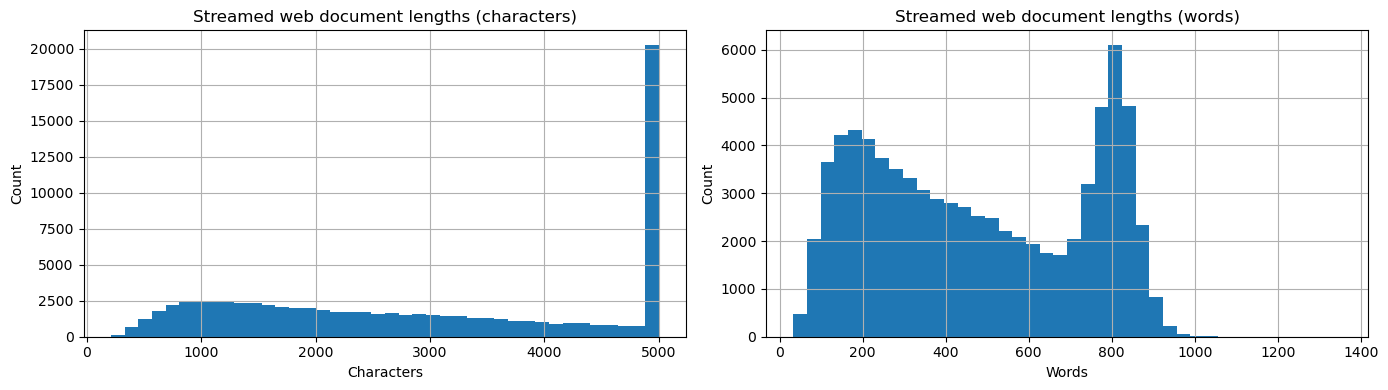


Preview of one streamed web document:

No. 24; Updated March 2011
Click here to download and print a PDF version of this document.
Parents are usually the first to recognize that their child has a problem with emotions or behavior. Still, the decision to seek professional help can be difficult and painful for a parent. The first step is to gently try to talk to the child. An honest open talk about feelings can often help. Parents may choose to consult with the child's physicians, teachers, members of the clergy, or other adults who know the child well. These steps may resolve the problems for the child and family.
Following are a few signs which may indicate that a child and adolescent psychiatric evaluation will be useful.
- Marked fall in school performance
- Poor grades in school despite trying very hard
- Severe worry or anxiety, as shown by regular refusal to go to school, go to sleep or take part in activities that are normal for the child's age
- Frequent physical complaints
- 

In [5]:
# ============================================================
# CELL 5: STREAM WEB CORPUS SAMPLE + CACHE
# ============================================================
# This cell:
# 1. Streams the web corpus
# 2. Extracts text robustly
# 3. Truncates giant outliers
# 4. Deduplicates exact duplicates
# 5. Caches the result with metadata
# ============================================================

require_globals(
    "web_corpus_choice",
    "training_max_streamed_docs",
    "max_chars_per_web_doc",
    "load_dataset",
    "CORPUS_DIR",
    "stable_text_hash",
    "save_json",
    "load_json",
)

web_cache_path = CORPUS_DIR / f"web_documents_{web_corpus_choice}_{training_max_streamed_docs}.json"
web_cache_meta_path = CORPUS_DIR / f"web_documents_{web_corpus_choice}_{training_max_streamed_docs}_meta.json"

def extract_text_from_row(row):
    candidate_keys = ["text", "content", "raw_content", "document", "article"]
    for key in candidate_keys:
        if key in row and row[key] is not None:
            text = str(row[key]).strip()
            if text:
                return text
    return None

def get_streaming_dataset(choice):
    if choice == "fineweb_edu":
        return load_dataset("HuggingFaceFW/fineweb-edu", split="train", streaming=True)
    elif choice == "fineweb":
        return load_dataset("HuggingFaceFW/fineweb", split="train", streaming=True)
    elif choice == "openwebtext":
        return load_dataset("Skylion007/openwebtext", split="train", streaming=True)
    else:
        raise ValueError(f"Unknown web_corpus_choice: {choice}")

def iter_streamed_texts(choice, max_docs):
    ds = get_streaming_dataset(choice)
    yielded = 0
    seen_hashes = set()

    for row in ds:
        text = extract_text_from_row(row)
        if text is None:
            continue

        text = text[:max_chars_per_web_doc].strip()
        if not text:
            continue

        h = stable_text_hash(text)
        if h in seen_hashes:
            continue
        seen_hashes.add(h)

        yield text
        yielded += 1
        if yielded >= max_docs:
            break

cache_ok = web_cache_path.exists() and web_cache_meta_path.exists()

if cache_ok:
    print("Loading cached streamed web documents from disk...")
    web_documents = load_json(web_cache_path, default=[])
    web_meta = load_json(web_cache_meta_path, default={})
else:
    print("Streaming web documents from source dataset...")
    web_documents = list(iter_streamed_texts(web_corpus_choice, training_max_streamed_docs))
    web_meta = {
        "web_corpus_choice": web_corpus_choice,
        "training_max_streamed_docs": training_max_streamed_docs,
        "max_chars_per_web_doc": max_chars_per_web_doc,
        "num_docs": len(web_documents),
        "timestamp": time.time(),
    }
    save_json(web_documents, web_cache_path)
    save_json(web_meta, web_cache_meta_path)

print(f"Loaded streamed web documents: {len(web_documents)}")

if len(web_documents) == 0:
    raise RuntimeError("No streamed web documents were loaded.")

web_lengths_chars = [len(doc) for doc in web_documents]
web_lengths_words = [len(doc.split()) for doc in web_documents]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(web_lengths_chars, bins=40)
axes[0].set_title("Streamed web document lengths (characters)")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Count")

axes[1].hist(web_lengths_words, bins=40)
axes[1].set_title("Streamed web document lengths (words)")
axes[1].set_xlabel("Words")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print("\nPreview of one streamed web document:\n")
print(web_documents[0][:1500])

print("\nCached sample path:")
print(web_cache_path)

print("\nCache metadata:")
print(json.dumps(web_meta, indent=2)[:1200])

Using cached phase corpora artifacts from disk.
Unique local segments : 12
Tokenizer total lines : 26817648
Base total lines      : 27376324
Adapt total lines     : 22348240

Saved artifacts:
- /home/b/bl/bluetopazzz/artifacts_500m_kb/data/corpus/segments_local.json
- /home/b/bl/bluetopazzz/artifacts_500m_kb/data/corpus/tokenizer_phase.txt
- /home/b/bl/bluetopazzz/artifacts_500m_kb/data/corpus/base_phase.txt
- /home/b/bl/bluetopazzz/artifacts_500m_kb/data/corpus/adapt_phase.txt
- /home/b/bl/bluetopazzz/artifacts_500m_kb/data/corpus/phase_manifest.json

Sample local segments:
- A Reimagined World: The Untraveled Path of Africa and the Arab Peninsula
- The last few centuries have witnessed the world evolving at an unprecedented rate, largely influenced by Western hegemony. But history, as we know, is often a consequence of a few pivotal decisions and events. It's cruci
- THE ARCHITECT: RISE OF A COVERT TECHNOLOGIST
- A field manual disguised as a novel.
- Every paycheck is a payload.

Sa

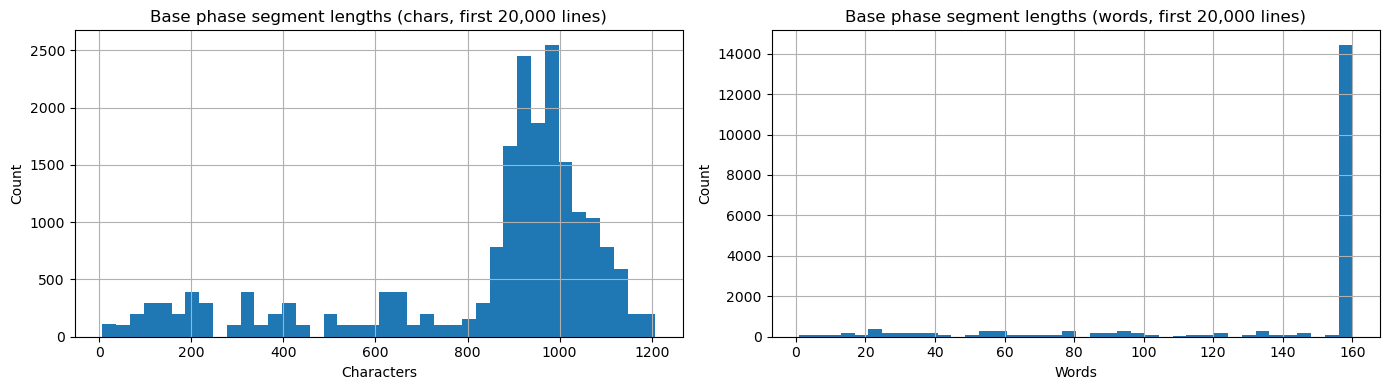

In [6]:
# ============================================================
# CELL 6: NORMALIZE, CLEAN, SEGMENT, AND BUILD PHASE CORPORA
# ============================================================
# This cell:
# 1. Cleans local text
# 2. Segments local + web text
# 3. Removes exact duplicates
# 4. Builds three phase corpora on disk:
#      - tokenizer_phase.txt
#      - base_phase.txt
#      - adapt_phase.txt
# 5. Caches metadata so reruns can skip all expensive work
#
# IMPORTANT:
# - FineWeb is already cleaned enough for this workflow
# - We do NOT do expensive web-text cleaning here
# - By default this cell reuses cached artifacts if they exist
# ============================================================

require_globals(
    "corpus_documents_local",
    "web_documents",
    "CORPUS_DIR",
    "PHASE_MIX_CONFIG",
    "web_chunk_words",
    "local_line_min_words",
    "stable_text_hash",
    "save_json",
)

from pathlib import Path
import json
import random
import re

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
segments_local_path = CORPUS_DIR / "segments_local.json"
tokenizer_phase_path = CORPUS_DIR / "tokenizer_phase.txt"
base_phase_path = CORPUS_DIR / "base_phase.txt"
adapt_phase_path = CORPUS_DIR / "adapt_phase.txt"
phase_manifest_path = CORPUS_DIR / "phase_manifest.json"

# ------------------------------------------------------------
# Cache control
# ------------------------------------------------------------
force_rebuild_phase_corpora = False

cached_outputs = [
    segments_local_path,
    tokenizer_phase_path,
    base_phase_path,
    adapt_phase_path,
    phase_manifest_path,
]

def manifest_get(d, *keys, default=None):
    for k in keys:
        if k in d:
            return d[k]
    return default

def file_nonempty(path: Path) -> bool:
    return path.exists() and path.stat().st_size > 0

cache_ready = all(file_nonempty(p) for p in cached_outputs)

use_cache = False
phase_manifest = None
segments_local = None

if cache_ready and not force_rebuild_phase_corpora:
    try:
        with open(segments_local_path, "r", encoding="utf-8") as f:
            segments_local = json.load(f)

        with open(phase_manifest_path, "r", encoding="utf-8") as f:
            phase_manifest = json.load(f)

        # Minimal schema validation across old/new manifest versions
        tokenizer_total_lines = manifest_get(
            phase_manifest,
            "tokenizer_total_lines",
            "tokenizer_segments_count",
        )
        base_total_lines = manifest_get(
            phase_manifest,
            "base_total_lines",
            "base_segments_count",
        )
        adapt_total_lines = manifest_get(
            phase_manifest,
            "adapt_total_lines",
            "adapt_segments_count",
        )
        unique_local_segments = manifest_get(
            phase_manifest,
            "unique_local_segments",
            "local_segments_count",
            "segments_local_count",
        )

        if (
            isinstance(segments_local, list)
            and len(segments_local) > 0
            and tokenizer_total_lines is not None
            and base_total_lines is not None
            and adapt_total_lines is not None
        ):
            use_cache = True
            print("Using cached phase corpora artifacts from disk.")
            print("Unique local segments :", unique_local_segments if unique_local_segments is not None else len(segments_local))
            print("Tokenizer total lines :", tokenizer_total_lines)
            print("Base total lines      :", base_total_lines)
            print("Adapt total lines     :", adapt_total_lines)
            print("\nSaved artifacts:")
            for p in cached_outputs:
                print("-", p)
        else:
            print("Cached phase manifest is incomplete. Rebuilding phase corpora...")

    except Exception as e:
        print(f"Cached phase artifacts could not be read cleanly ({repr(e)}). Rebuilding phase corpora...")

if not use_cache:
    print("Building phase corpora from source documents...")

    # --------------------------------------------------------
    # Local text cleaning only
    # --------------------------------------------------------
    def normalize_text(text: str) -> str:
        lines = text.splitlines()
        cleaned_lines = []
        for line in lines:
            line = re.sub(r"\s+", " ", line).strip()
            if line:
                cleaned_lines.append(line)
        return "\n".join(cleaned_lines)

    def clean_local_text(text: str) -> str:
        text = normalize_text(text)

        cleaned_lines = []
        for line in text.split("\n"):
            line = re.sub(r"^\s{0,3}#{1,6}\s*", "", line).strip()
            if line:
                cleaned_lines.append(line)

        return "\n".join(cleaned_lines).strip()

    def split_local_document(text: str):
        lines = [line.strip() for line in text.split("\n") if line.strip()]
        out = []
        for line in lines:
            if len(line.split()) >= local_line_min_words:
                out.append(line)
        return out

    # --------------------------------------------------------
    # Web segmentation only
    # --------------------------------------------------------
    def chunk_long_text(text, max_words=160):
        words = text.split()
        chunks = []
        for i in range(0, len(words), max_words):
            chunk = " ".join(words[i:i + max_words]).strip()
            if chunk:
                chunks.append(chunk)
        return chunks

    def dedupe_segments(segments):
        seen = set()
        out = []
        for s in segments:
            s = s.strip()
            if not s:
                continue
            h = stable_text_hash(s)
            if h in seen:
                continue
            seen.add(h)
            out.append(s)
        return out

    # --------------------------------------------------------
    # Build local segments
    # --------------------------------------------------------
    normalized_local_docs = [clean_local_text(doc) for doc in corpus_documents_local]

    segments_local = []
    for doc in normalized_local_docs:
        segments_local.extend(split_local_document(doc))

    segments_local = dedupe_segments(segments_local)

    if len(segments_local) == 0:
        raise RuntimeError("No local segments survived cleaning.")

    # --------------------------------------------------------
    # Write weighted corpora directly to disk
    # --------------------------------------------------------
    def write_weighted_phase_file(
        output_path: Path,
        local_segments,
        web_documents,
        local_weight: int,
        web_weight: int,
        chunk_words: int,
        seed: int,
    ):
        rng = random.Random(seed)
        line_count = 0

        with open(output_path, "w", encoding="utf-8") as out:
            local_pool = local_segments * local_weight
            rng.shuffle(local_pool)

            for s in local_pool:
                out.write(s + "\n")
                line_count += 1

            for doc in web_documents:
                chunks = chunk_long_text(doc, max_words=chunk_words)
                if not chunks:
                    continue

                for _ in range(web_weight):
                    chunk_copy = list(chunks)
                    rng.shuffle(chunk_copy)
                    for s in chunk_copy:
                        out.write(s + "\n")
                        line_count += 1

        return line_count

    tokenizer_total_lines = write_weighted_phase_file(
        tokenizer_phase_path,
        local_segments=segments_local,
        web_documents=web_documents,
        local_weight=PHASE_MIX_CONFIG["tokenizer"]["local_weight"],
        web_weight=PHASE_MIX_CONFIG["tokenizer"]["web_weight"],
        chunk_words=web_chunk_words,
        seed=SEED + 11,
    )

    base_total_lines = write_weighted_phase_file(
        base_phase_path,
        local_segments=segments_local,
        web_documents=web_documents,
        local_weight=PHASE_MIX_CONFIG["base"]["local_weight"],
        web_weight=PHASE_MIX_CONFIG["base"]["web_weight"],
        chunk_words=web_chunk_words,
        seed=SEED + 21,
    )

    adapt_total_lines = write_weighted_phase_file(
        adapt_phase_path,
        local_segments=segments_local,
        web_documents=web_documents,
        local_weight=PHASE_MIX_CONFIG["adapt"]["local_weight"],
        web_weight=PHASE_MIX_CONFIG["adapt"]["web_weight"],
        chunk_words=web_chunk_words,
        seed=SEED + 31,
    )

    save_json(segments_local, segments_local_path)

    phase_manifest = {
        "unique_local_segments": len(segments_local),
        "tokenizer_total_lines": tokenizer_total_lines,
        "base_total_lines": base_total_lines,
        "adapt_total_lines": adapt_total_lines,
        "tokenizer_phase_path": str(tokenizer_phase_path),
        "base_phase_path": str(base_phase_path),
        "adapt_phase_path": str(adapt_phase_path),
    }
    save_json(phase_manifest, phase_manifest_path)

    print("Unique local segments :", len(segments_local))
    print("Tokenizer total lines :", tokenizer_total_lines)
    print("Base total lines      :", base_total_lines)
    print("Adapt total lines     :", adapt_total_lines)

    print("\nSaved artifacts:")
    for p in cached_outputs:
        print("-", p)

# ------------------------------------------------------------
# Expose paths for downstream cells
# ------------------------------------------------------------
tokenizer_segments_path = tokenizer_phase_path
base_segments_path = base_phase_path
adapt_segments_path = adapt_phase_path

# ------------------------------------------------------------
# Lightweight diagnostics
# ------------------------------------------------------------
print("\nSample local segments:")
for s in segments_local[:5]:
    print("-", s[:220])

print("\nSample base segments:")
shown = 0
with open(base_segments_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            print("-", line[:220])
            shown += 1
            if shown >= 5:
                break

preview_char_lengths = []
preview_word_lengths = []
preview_limit = 20000

with open(base_segments_path, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i >= preview_limit:
            break
        line = line.strip()
        if not line:
            continue
        preview_char_lengths.append(len(line))
        preview_word_lengths.append(len(line.split()))

if preview_char_lengths:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].hist(preview_char_lengths, bins=40)
    axes[0].set_title(f"Base phase segment lengths (chars, first {len(preview_char_lengths):,} lines)")
    axes[0].set_xlabel("Characters")
    axes[0].set_ylabel("Count")

    axes[1].hist(preview_word_lengths, bins=40)
    axes[1].set_title(f"Base phase segment lengths (words, first {len(preview_word_lengths):,} lines)")
    axes[1].set_xlabel("Words")
    axes[1].set_ylabel("Count")

    plt.tight_layout()
    plt.show()
else:
    print("No preview lines found in base phase file.")

In [7]:
# ============================================================
# CELL 7: TRAIN OR LOAD TOKENIZER, THEN ENCODE BASE/ADAPT TO DISK
# ============================================================
# This cell:
# 1. Loads cached phase corpus artifacts from CELL 6
# 2. Trains or loads a SentencePiece tokenizer
# 3. Uses a sampled tokenizer training file to avoid kernel death
# 4. Encodes base/adapt corpora into flat token streams on disk
# 5. Avoids giant in-memory merges during token export
# 6. Recreates notebook globals needed by later cells
# ============================================================

require_globals(
    "CORPUS_DIR",
    "TOKENIZER_DIR",
    "DATA_DIR",
    "spm",
    "sp_vocab_size",
    "sp_model_type",
    "sp_character_coverage",
)

from pathlib import Path
import json
import numpy as np
import gc

# ------------------------------------------------------------
# Inputs from CELL 6
# ------------------------------------------------------------
segments_local_path = CORPUS_DIR / "segments_local.json"
tokenizer_phase_path = CORPUS_DIR / "tokenizer_phase.txt"
base_phase_path = CORPUS_DIR / "base_phase.txt"
adapt_phase_path = CORPUS_DIR / "adapt_phase.txt"
phase_manifest_path = CORPUS_DIR / "phase_manifest.json"

required_inputs = [
    segments_local_path,
    tokenizer_phase_path,
    base_phase_path,
    adapt_phase_path,
    phase_manifest_path,
]

missing_inputs = [p for p in required_inputs if not p.exists()]
if missing_inputs:
    raise RuntimeError(
        "Missing required cached corpus artifacts:\n"
        + "\n".join(f"- {p}" for p in missing_inputs)
    )

with open(phase_manifest_path, "r", encoding="utf-8") as f:
    phase_manifest = json.load(f)

def manifest_get(d, *keys, default=None):
    for k in keys:
        if k in d:
            return d[k]
    return default

# Recreate globals needed later
tokenizer_segments_path = tokenizer_phase_path
base_segments_path = base_phase_path
adapt_segments_path = adapt_phase_path

print("Unique local segments :", manifest_get(
    phase_manifest,
    "unique_local_segments",
    "local_segments_count",
    "segments_local_count",
    default="unknown",
))
print("Tokenizer total lines :", manifest_get(
    phase_manifest,
    "tokenizer_total_lines",
    "tokenizer_segments_count",
    default="unknown",
))
print("Base total lines      :", manifest_get(
    phase_manifest,
    "base_total_lines",
    "base_segments_count",
    default="unknown",
))
print("Adapt total lines     :", manifest_get(
    phase_manifest,
    "adapt_total_lines",
    "adapt_segments_count",
    default="unknown",
))

# ------------------------------------------------------------
# Tokenizer paths
# ------------------------------------------------------------
sp_model_prefix = str(TOKENIZER_DIR / f"kb_spm_{sp_vocab_size}")
model_path = Path(f"{sp_model_prefix}.model")
vocab_path = Path(f"{sp_model_prefix}.vocab")

# Instead of training on the full gigantic repeated corpus file,
# create a sampled tokenizer training file.
sampled_tokenizer_corpus_path = TOKENIZER_DIR / f"kb_tokenizer_sampled_{sp_vocab_size}.txt"

# ------------------------------------------------------------
# Token stream outputs
# ------------------------------------------------------------
base_tokens_path = DATA_DIR / "base_tokens.npy"
adapt_tokens_path = DATA_DIR / "adapt_tokens.npy"
tokenizer_manifest_path = DATA_DIR / "tokenizer_manifest.json"

tmp_chunk_dir = DATA_DIR / "token_chunks"
tmp_chunk_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Cache control
# ------------------------------------------------------------
force_retrain_tokenizer = False
force_rebuild_tokenizer_sample = False
force_reencode_phase_tokens = False

# ------------------------------------------------------------
# Build sampled tokenizer corpus
# ------------------------------------------------------------
def build_sampled_tokenizer_corpus(
    source_path: Path,
    output_path: Path,
    max_lines: int = 1_000_000,
    stride: int = 25,
    force_rebuild: bool = False,
):
    """
    Build a much smaller tokenizer training corpus from the
    cached tokenizer phase file.

    We do not need tens of millions of repeated lines to train
    SentencePiece well for this run.
    """
    if output_path.exists() and not force_rebuild:
        print(f"Using existing sampled tokenizer corpus: {output_path}")
        return output_path

    print(f"Building sampled tokenizer corpus: {output_path}")

    kept = 0
    seen = 0
    with open(source_path, "r", encoding="utf-8") as fin, open(output_path, "w", encoding="utf-8") as fout:
        for line in fin:
            text = line.strip()
            if not text:
                continue

            # Keep all local-ish rare lines near the top naturally,
            # then stride sample the giant repeated mixture.
            if seen % stride == 0:
                fout.write(text + "\n")
                kept += 1
                if kept >= max_lines:
                    break
            seen += 1

    print(f"Sampled tokenizer lines kept: {kept:,}")
    return output_path

sp_corpus_file = build_sampled_tokenizer_corpus(
    tokenizer_phase_path,
    sampled_tokenizer_corpus_path,
    max_lines=1_000_000,
    stride=25,
    force_rebuild=force_rebuild_tokenizer_sample,
)

# ------------------------------------------------------------
# Train or load tokenizer
# ------------------------------------------------------------
if force_retrain_tokenizer or not model_path.exists() or not vocab_path.exists():
    print("Training SentencePiece tokenizer from sampled corpus ...")
    spm.SentencePieceTrainer.Train(
        input=str(sp_corpus_file),
        model_prefix=sp_model_prefix,
        vocab_size=sp_vocab_size,
        model_type=sp_model_type,
        character_coverage=sp_character_coverage,
        bos_id=1,
        eos_id=2,
        pad_id=0,
        unk_id=3,
        shuffle_input_sentence=True,
        input_sentence_size=1_000_000,
        train_extremely_large_corpus=False,
    )
else:
    print("Using existing tokenizer files on disk.")

sp = spm.SentencePieceProcessor()
sp.load(str(model_path))

vocab_size = sp.get_piece_size()
PAD_ID = sp.pad_id()
BOS_ID = sp.bos_id()
EOS_ID = sp.eos_id()
UNK_ID = sp.unk_id()

def encode(text):
    return sp.encode(text, out_type=int)

def decode(ids):
    ids = [int(x) for x in ids]
    return sp.decode(ids)

def piece(i):
    return sp.id_to_piece(int(i))

# ------------------------------------------------------------
# Safer disk-backed encoding helpers
# ------------------------------------------------------------
def write_chunk_file(chunk_path: Path, token_buffer):
    arr = np.asarray(token_buffer, dtype=np.int32)
    np.save(chunk_path, arr)
    return int(arr.shape[0])

def merge_chunk_files_to_npy(chunk_paths, output_path: Path, dtype=np.int32):
    """
    Merge chunk .npy files into one final .npy without loading
    the entire corpus into RAM at once.
    """
    if not chunk_paths:
        raise RuntimeError("No chunk files to merge.")

    # First pass: total size
    total_tokens = 0
    chunk_lengths = []
    for p in chunk_paths:
        arr = np.load(p, mmap_mode="r")
        n = int(arr.shape[0])
        chunk_lengths.append(n)
        total_tokens += n

    # Allocate final memmap-backed array
    merged_memmap_path = output_path.with_suffix(".mmap")
    merged = np.memmap(merged_memmap_path, mode="w+", dtype=dtype, shape=(total_tokens,))

    # Second pass: copy chunk by chunk
    cursor = 0
    for p, n in zip(chunk_paths, chunk_lengths):
        arr = np.load(p, mmap_mode="r")
        merged[cursor:cursor + n] = arr[:]
        cursor += n

    merged.flush()
    del merged
    gc.collect()

    # Reopen memmap and save to final .npy
    final_arr = np.memmap(merged_memmap_path, mode="r", dtype=dtype, shape=(total_tokens,))
    np.save(output_path, np.asarray(final_arr))
    del final_arr
    gc.collect()

    try:
        merged_memmap_path.unlink()
    except Exception:
        pass

    return total_tokens

def encode_phase_file_to_tokens(
    input_path: Path,
    output_path: Path,
    eos_id: int,
    tmp_prefix: str,
    force_rebuild: bool = False,
    progress_every: int = 250_000,
    flush_token_budget: int = 2_000_000,
):
    """
    Encode a phase text file into one flat token stream on disk,
    using chunk files + disk-backed merge to avoid RAM blowups.
    """
    if output_path.exists() and not force_rebuild:
        arr = np.load(output_path, mmap_mode="r")
        print(f"Using cached token stream: {output_path} | shape={arr.shape}")
        return output_path, int(arr.shape[0])

    print(f"Encoding token stream from: {input_path}")

    chunk_paths = []
    token_buffer = []
    line_count = 0
    chunk_idx = 0

    with open(input_path, "r", encoding="utf-8") as f:
        for line in f:
            text = line.strip()
            if not text:
                continue

            ids = sp.encode(text, out_type=int)
            token_buffer.extend(ids)
            token_buffer.append(eos_id)
            line_count += 1

            if len(token_buffer) >= flush_token_budget:
                chunk_path = tmp_chunk_dir / f"{tmp_prefix}_chunk_{chunk_idx:05d}.npy"
                write_chunk_file(chunk_path, token_buffer)
                chunk_paths.append(chunk_path)
                token_buffer = []
                chunk_idx += 1
                gc.collect()

            if progress_every and line_count % progress_every == 0:
                print(f"  encoded {line_count:,} lines so far ...")

    if token_buffer:
        chunk_path = tmp_chunk_dir / f"{tmp_prefix}_chunk_{chunk_idx:05d}.npy"
        write_chunk_file(chunk_path, token_buffer)
        chunk_paths.append(chunk_path)
        token_buffer = []
        gc.collect()

    if not chunk_paths:
        raise RuntimeError(f"No tokens were produced from {input_path}")

    total_tokens = merge_chunk_files_to_npy(chunk_paths, output_path, dtype=np.int32)

    for p in chunk_paths:
        try:
            p.unlink()
        except Exception:
            pass

    print(f"Saved token stream: {output_path} | shape=({total_tokens},)")
    return output_path, int(total_tokens)

# ------------------------------------------------------------
# Encode base and adapt phases
# ------------------------------------------------------------
base_tokens_path, base_token_count = encode_phase_file_to_tokens(
    base_phase_path,
    base_tokens_path,
    eos_id=EOS_ID,
    tmp_prefix="base",
    force_rebuild=force_reencode_phase_tokens,
)

adapt_tokens_path, adapt_token_count = encode_phase_file_to_tokens(
    adapt_phase_path,
    adapt_tokens_path,
    eos_id=EOS_ID,
    tmp_prefix="adapt",
    force_rebuild=force_reencode_phase_tokens,
)

# ------------------------------------------------------------
# Small previews only
# ------------------------------------------------------------
sample_base_segments = []
with open(base_phase_path, "r", encoding="utf-8") as f:
    for line in f:
        text = line.strip()
        if text:
            sample_base_segments.append(text)
        if len(sample_base_segments) >= 8:
            break

sample_adapt_segments = []
with open(adapt_phase_path, "r", encoding="utf-8") as f:
    for line in f:
        text = line.strip()
        if text:
            sample_adapt_segments.append(text)
        if len(sample_adapt_segments) >= 8:
            break

encoded_segments_base_preview = [encode(s) for s in sample_base_segments]
encoded_segments_adapt_preview = [encode(s) for s in sample_adapt_segments]

# ------------------------------------------------------------
# Save manifest
# ------------------------------------------------------------
tokenizer_manifest = {
    "tokenizer_model": str(model_path),
    "tokenizer_vocab": str(vocab_path),
    "tokenizer_training_corpus": str(sp_corpus_file),
    "sp_vocab_size_requested": int(sp_vocab_size),
    "vocab_size_actual": int(vocab_size),
    "pad_id": int(PAD_ID),
    "bos_id": int(BOS_ID),
    "eos_id": int(EOS_ID),
    "unk_id": int(UNK_ID),
    "base_phase_path": str(base_phase_path),
    "adapt_phase_path": str(adapt_phase_path),
    "base_tokens_path": str(base_tokens_path),
    "adapt_tokens_path": str(adapt_tokens_path),
    "base_token_count": int(base_token_count),
    "adapt_token_count": int(adapt_token_count),
}

with open(tokenizer_manifest_path, "w", encoding="utf-8") as f:
    json.dump(tokenizer_manifest, f, indent=2)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------
print("\nTokenizer ready.")
print("Tokenizer model :", model_path)
print("Tokenizer vocab :", vocab_path)
print("Tokenizer train :", sp_corpus_file)
print("Vocabulary size :", vocab_size)
print("PAD/BOS/EOS/UNK :", PAD_ID, BOS_ID, EOS_ID, UNK_ID)

print("\nToken streams:")
print("Base  tokens path :", base_tokens_path)
print("Base  token count :", f"{base_token_count:,}")
print("Adapt tokens path :", adapt_tokens_path)
print("Adapt token count :", f"{adapt_token_count:,}")

print("\nSaved tokenizer manifest:")
print(tokenizer_manifest_path)

if sample_base_segments:
    example = sample_base_segments[0]
    print("\nOriginal example:")
    print(example)

    print("\nEncoded IDs:")
    print(encode(example)[:40])

    print("\nPieces:")
    print([piece(i) for i in encode(example)[:40]])

    print("\nDecoded back:")
    print(decode(encode(example)))

Unique local segments : 12
Tokenizer total lines : 26817648
Base total lines      : 27376324
Adapt total lines     : 22348240
Building sampled tokenizer corpus: /home/b/bl/bluetopazzz/artifacts_500m_kb/tokenizer/kb_tokenizer_sampled_16000.txt
Sampled tokenizer lines kept: 1,000,000
Training SentencePiece tokenizer from sampled corpus ...


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: /home/b/bl/bluetopazzz/artifacts_500m_kb/tokenizer/kb_tokenizer_sampled_16000.txt
  input_format: 
  model_prefix: /home/b/bl/bluetopazzz/artifacts_500m_kb/tokenizer/kb_spm_16000
  model_type: UNIGRAM
  vocab_size: 16000
  self_test_sample_size: 0
  character_coverage: 1
  input_sentence_size: 1000000
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_p

Encoding token stream from: /home/b/bl/bluetopazzz/artifacts_500m_kb/data/corpus/base_phase.txt
  encoded 250,000 lines so far ...
  encoded 500,000 lines so far ...
  encoded 750,000 lines so far ...
  encoded 1,000,000 lines so far ...
  encoded 1,250,000 lines so far ...
  encoded 1,500,000 lines so far ...
  encoded 1,750,000 lines so far ...
  encoded 2,000,000 lines so far ...
  encoded 2,250,000 lines so far ...
  encoded 2,500,000 lines so far ...
  encoded 2,750,000 lines so far ...
  encoded 3,000,000 lines so far ...
  encoded 3,250,000 lines so far ...
  encoded 3,500,000 lines so far ...
  encoded 3,750,000 lines so far ...
  encoded 4,000,000 lines so far ...
  encoded 4,250,000 lines so far ...
  encoded 4,500,000 lines so far ...
  encoded 4,750,000 lines so far ...
  encoded 5,000,000 lines so far ...
  encoded 5,250,000 lines so far ...
  encoded 5,500,000 lines so far ...
  encoded 5,750,000 lines so far ...
  encoded 6,000,000 lines so far ...
  encoded 6,250,000 li

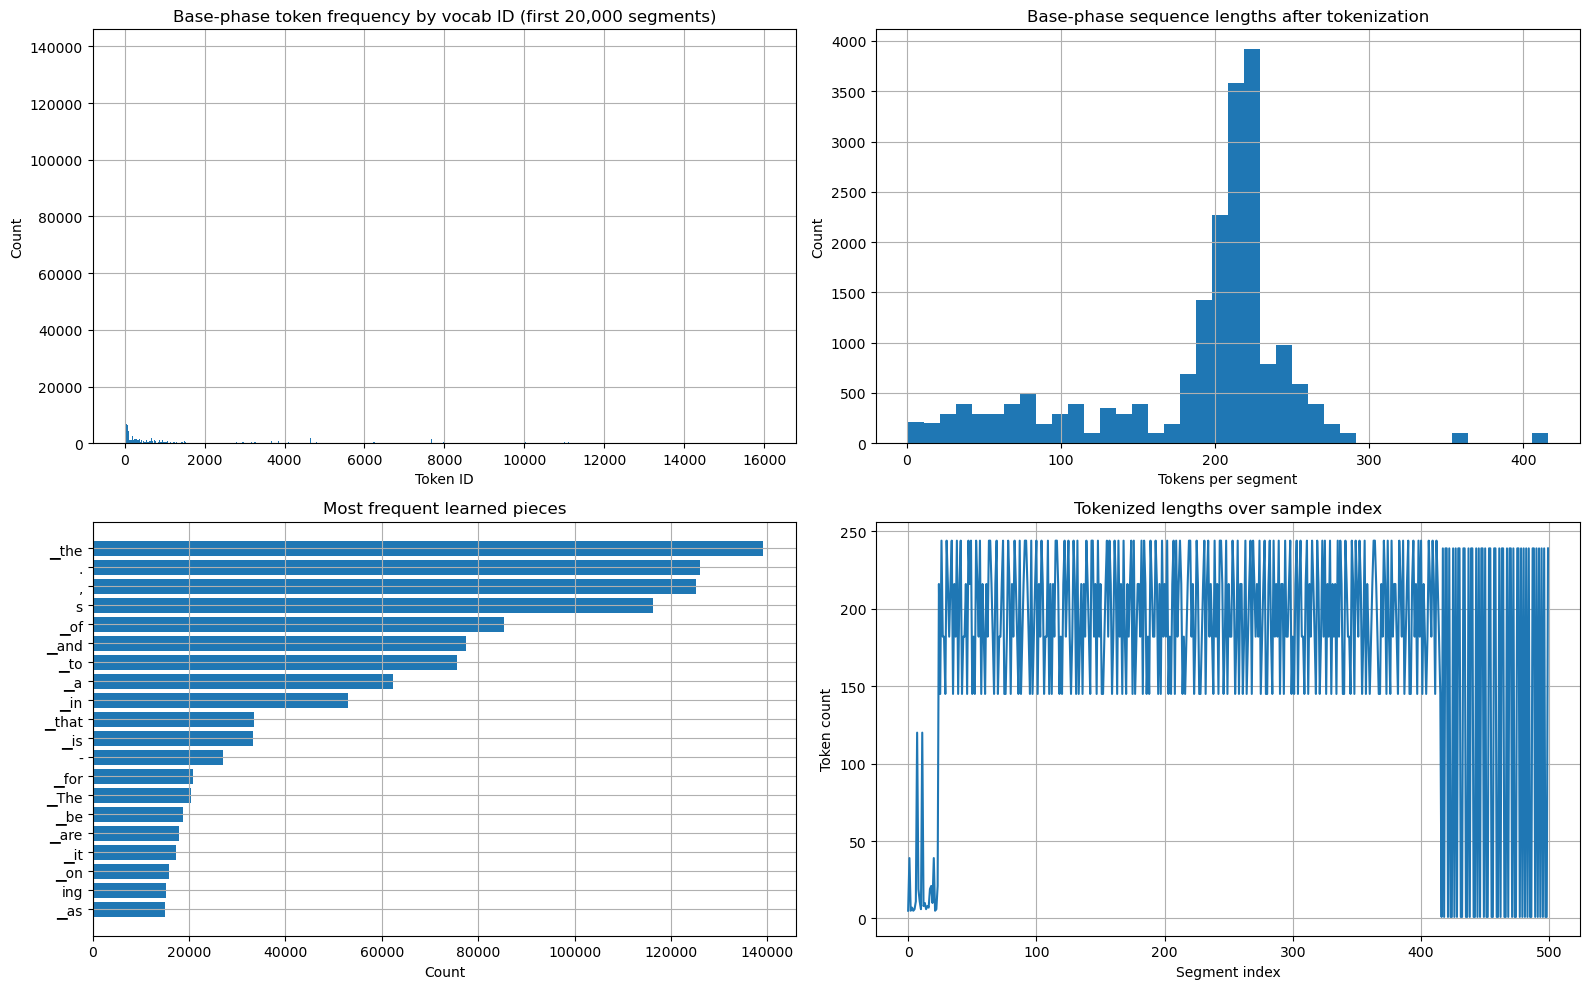

Preview segments used: 20000
Example token pieces from preview base segment 0:
['▁-', '▁Sa', 'hel', '▁Development', '▁Fund']


In [8]:
# ============================================================
# CELL 7B: TOKENIZER DIAGNOSTICS DASHBOARD
# ============================================================
# This cell diagnoses tokenizer behavior using lightweight
# previews from the BASE phase text file instead of requiring
# giant in-memory encoded segment lists.
# ============================================================

require_globals("base_segments_path", "encode", "piece", "vocab_size")

import numpy as np

preview_segment_limit = 20000

base_segments_preview = []
with open(base_segments_path, "r", encoding="utf-8") as f:
    for line in f:
        text = line.strip()
        if text:
            base_segments_preview.append(text)
        if len(base_segments_preview) >= preview_segment_limit:
            break

if not base_segments_preview:
    raise RuntimeError("No preview segments found in base phase file.")

encoded_segments_base = [encode(s) for s in base_segments_preview]

token_counts = np.zeros(vocab_size, dtype=np.int64)
for seq in encoded_segments_base:
    for t in seq:
        token_counts[int(t)] += 1

token_lengths = [len(seq) for seq in encoded_segments_base]

top_ids = np.argsort(token_counts)[::-1][:20]
top_ids = [int(i) for i in top_ids]
top_pieces = [piece(i) for i in top_ids]
top_counts = token_counts[top_ids]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].bar(range(vocab_size), token_counts)
axes[0, 0].set_title(f"Base-phase token frequency by vocab ID (first {len(encoded_segments_base):,} segments)")
axes[0, 0].set_xlabel("Token ID")
axes[0, 0].set_ylabel("Count")

axes[0, 1].hist(token_lengths, bins=40)
axes[0, 1].set_title("Base-phase sequence lengths after tokenization")
axes[0, 1].set_xlabel("Tokens per segment")
axes[0, 1].set_ylabel("Count")

axes[1, 0].barh(range(len(top_pieces)), top_counts[::-1])
axes[1, 0].set_yticks(range(len(top_pieces)))
axes[1, 0].set_yticklabels(top_pieces[::-1])
axes[1, 0].set_title("Most frequent learned pieces")
axes[1, 0].set_xlabel("Count")

axes[1, 1].plot(token_lengths[:500])
axes[1, 1].set_title("Tokenized lengths over sample index")
axes[1, 1].set_xlabel("Segment index")
axes[1, 1].set_ylabel("Token count")

plt.tight_layout()
plt.show()

print("Preview segments used:", len(base_segments_preview))
print("Example token pieces from preview base segment 0:")
print([piece(i) for i in encoded_segments_base[0][:60]])

Loaded flat token streams:
 - /home/b/bl/bluetopazzz/artifacts_500m_kb/data/base_tokens.npy (5306562554,)
 - /home/b/bl/bluetopazzz/artifacts_500m_kb/data/adapt_tokens.npy (4331892740,)



Saved phase-specific token splits:
 - /home/b/bl/bluetopazzz/artifacts_500m_kb/data/phase_tokens/base_train_tokens.npy (5041234426,)
 - /home/b/bl/bluetopazzz/artifacts_500m_kb/data/phase_tokens/base_val_tokens.npy (265328128,)
 - /home/b/bl/bluetopazzz/artifacts_500m_kb/data/phase_tokens/adapt_train_tokens.npy (4115298103,)
 - /home/b/bl/bluetopazzz/artifacts_500m_kb/data/phase_tokens/adapt_val_tokens.npy (216594637,)

Saved split manifest:
 - /home/b/bl/bluetopazzz/artifacts_500m_kb/data/phase_tokens/phase_split_manifest.json


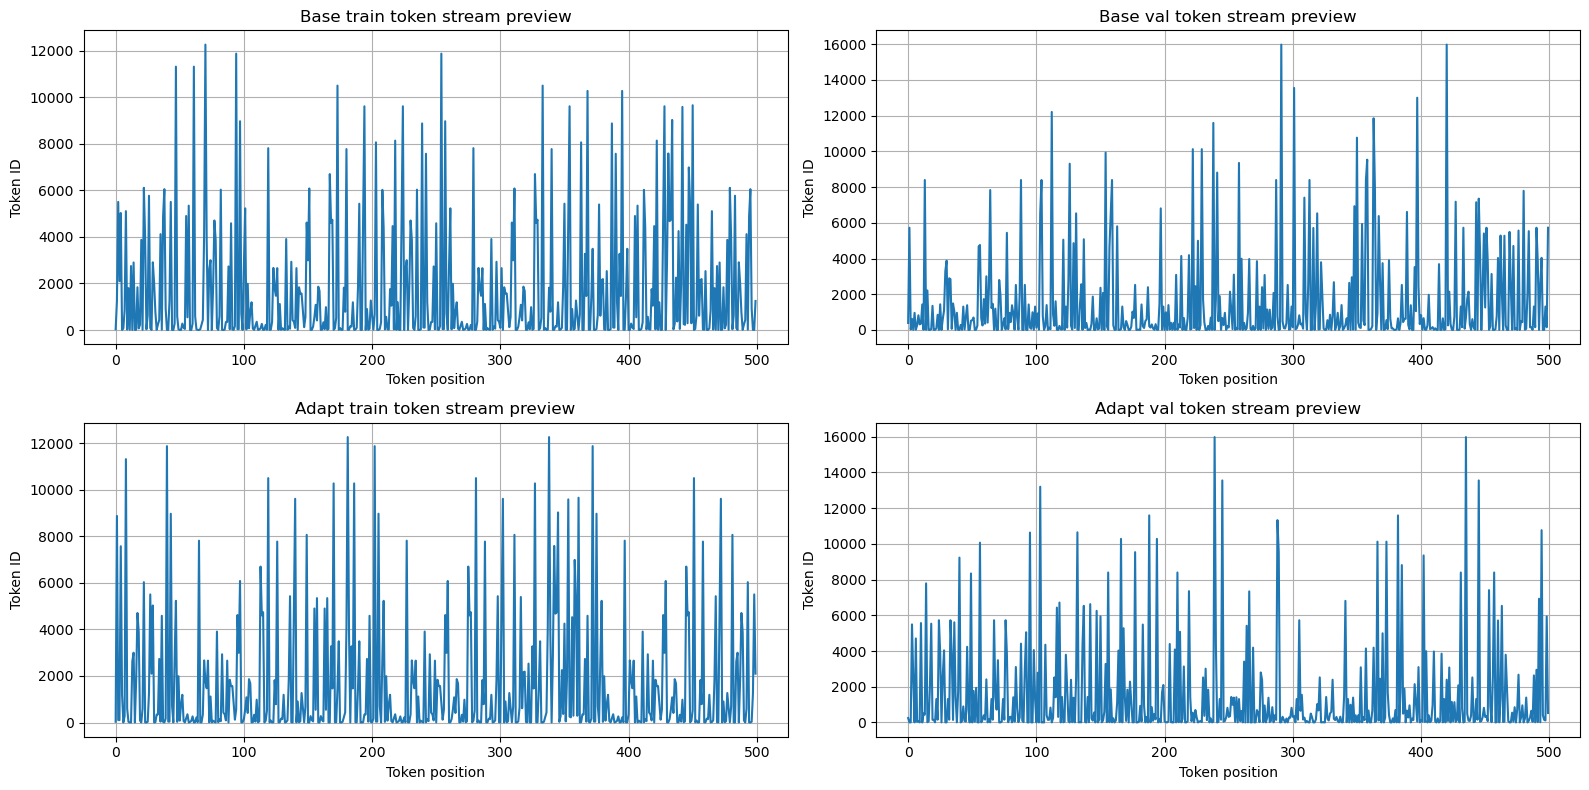

In [22]:
# ============================================================
# CELL 8: BUILD PHASE-SPECIFIC TOKEN STREAMS AND SAVE THEM
# ============================================================
# This refactored cell assumes CELL 7 already wrote:
# - base_tokens.npy
# - adapt_tokens.npy
#
# Responsibilities:
# 1. Load cached flat token streams from disk
# 2. Split each phase into train / validation streams
# 3. Save phase-specific train/val token files
# 4. Avoid any dependence on giant in-memory encoded segment lists
#
# IMPORTANT:
# - We split token streams by position, not by segment objects
# - This matches the current disk-backed preprocessing design
# ============================================================

require_globals("DATA_DIR", "EOS_ID")

from pathlib import Path
import json
import numpy as np

# ------------------------------------------------------------
# Paths from CELL 7 outputs
# ------------------------------------------------------------
base_tokens_path = DATA_DIR / "base_tokens.npy"
adapt_tokens_path = DATA_DIR / "adapt_tokens.npy"

if not base_tokens_path.exists():
    raise RuntimeError(f"Missing base token stream: {base_tokens_path}")
if not adapt_tokens_path.exists():
    raise RuntimeError(f"Missing adapt token stream: {adapt_tokens_path}")

PHASE_DATA_DIR = DATA_DIR / "phase_tokens"
PHASE_DATA_DIR.mkdir(parents=True, exist_ok=True)

base_train_path = PHASE_DATA_DIR / "base_train_tokens.npy"
base_val_path = PHASE_DATA_DIR / "base_val_tokens.npy"
adapt_train_path = PHASE_DATA_DIR / "adapt_train_tokens.npy"
adapt_val_path = PHASE_DATA_DIR / "adapt_val_tokens.npy"

phase_split_manifest_path = PHASE_DATA_DIR / "phase_split_manifest.json"

# ------------------------------------------------------------
# Config
# ------------------------------------------------------------
block_size = 1024
token_val_fraction = 0.05

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def load_token_stream(path: Path):
    arr = np.load(path, mmap_mode="r")
    if arr.ndim != 1:
        raise RuntimeError(f"Expected 1D token stream at {path}, got shape {arr.shape}")
    return arr

def split_token_stream(arr, val_fraction=0.05):
    n = int(arr.shape[0])
    if n <= block_size + 1:
        raise RuntimeError(
            f"Token stream too short for block_size={block_size}. "
            f"Need > {block_size + 1} tokens, got {n}."
        )

    split_idx = int((1.0 - val_fraction) * n)

    # Keep both sides large enough for next-token windows
    split_idx = max(split_idx, block_size + 1)
    split_idx = min(split_idx, n - (block_size + 1))

    train_tokens = np.asarray(arr[:split_idx], dtype=np.int32)
    val_tokens = np.asarray(arr[split_idx:], dtype=np.int32)

    if train_tokens.shape[0] <= block_size + 1:
        raise RuntimeError("Train split too short after split.")
    if val_tokens.shape[0] <= block_size + 1:
        raise RuntimeError("Val split too short after split.")

    return train_tokens, val_tokens, split_idx

def save_split(train_tokens, val_tokens, train_path: Path, val_path: Path):
    np.save(train_path, train_tokens)
    np.save(val_path, val_tokens)

# ------------------------------------------------------------
# Load flat token streams
# ------------------------------------------------------------
base_tokens = load_token_stream(base_tokens_path)
adapt_tokens = load_token_stream(adapt_tokens_path)

print("Loaded flat token streams:")
print(" -", base_tokens_path, base_tokens.shape)
print(" -", adapt_tokens_path, adapt_tokens.shape)

# ------------------------------------------------------------
# Split base phase
# ------------------------------------------------------------
base_train_tokens, base_val_tokens, base_split_idx = split_token_stream(
    base_tokens,
    val_fraction=token_val_fraction,
)

save_split(base_train_tokens, base_val_tokens, base_train_path, base_val_path)

# ------------------------------------------------------------
# Split adapt phase
# ------------------------------------------------------------
adapt_train_tokens, adapt_val_tokens, adapt_split_idx = split_token_stream(
    adapt_tokens,
    val_fraction=token_val_fraction,
)

save_split(adapt_train_tokens, adapt_val_tokens, adapt_train_path, adapt_val_path)

# ------------------------------------------------------------
# Save manifest
# ------------------------------------------------------------
phase_split_manifest = {
    "block_size": int(block_size),
    "token_val_fraction": float(token_val_fraction),
    "eos_id": int(EOS_ID),

    "base_tokens_path": str(base_tokens_path),
    "base_total_tokens": int(base_tokens.shape[0]),
    "base_split_idx": int(base_split_idx),
    "base_train_tokens_path": str(base_train_path),
    "base_train_tokens": int(base_train_tokens.shape[0]),
    "base_val_tokens_path": str(base_val_path),
    "base_val_tokens": int(base_val_tokens.shape[0]),

    "adapt_tokens_path": str(adapt_tokens_path),
    "adapt_total_tokens": int(adapt_tokens.shape[0]),
    "adapt_split_idx": int(adapt_split_idx),
    "adapt_train_tokens_path": str(adapt_train_path),
    "adapt_train_tokens": int(adapt_train_tokens.shape[0]),
    "adapt_val_tokens_path": str(adapt_val_path),
    "adapt_val_tokens": int(adapt_val_tokens.shape[0]),
}

with open(phase_split_manifest_path, "w", encoding="utf-8") as f:
    json.dump(phase_split_manifest, f, indent=2)

# ------------------------------------------------------------
# Export notebook globals expected by downstream cells
# ------------------------------------------------------------
base_train_tokens_path = base_train_path
base_val_tokens_path = base_val_path
adapt_train_tokens_path = adapt_train_path
adapt_val_tokens_path = adapt_val_path

print("\nSaved phase-specific token splits:")
print(" -", base_train_path, base_train_tokens.shape)
print(" -", base_val_path, base_val_tokens.shape)
print(" -", adapt_train_path, adapt_train_tokens.shape)
print(" -", adapt_val_path, adapt_val_tokens.shape)

print("\nSaved split manifest:")
print(" -", phase_split_manifest_path)

# ------------------------------------------------------------
# Lightweight diagnostics
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

axes[0, 0].plot(base_train_tokens[:500])
axes[0, 0].set_title("Base train token stream preview")
axes[0, 0].set_xlabel("Token position")
axes[0, 0].set_ylabel("Token ID")

axes[0, 1].plot(base_val_tokens[:500])
axes[0, 1].set_title("Base val token stream preview")
axes[0, 1].set_xlabel("Token position")
axes[0, 1].set_ylabel("Token ID")

axes[1, 0].plot(adapt_train_tokens[:500])
axes[1, 0].set_title("Adapt train token stream preview")
axes[1, 0].set_xlabel("Token position")
axes[1, 0].set_ylabel("Token ID")

axes[1, 1].plot(adapt_val_tokens[:500])
axes[1, 1].set_title("Adapt val token stream preview")
axes[1, 1].set_xlabel("Token position")
axes[1, 1].set_ylabel("Token ID")

plt.tight_layout()
plt.show()

Active phase: base
Train path  : /home/b/bl/bluetopazzz/artifacts_500m_kb/data/phase_tokens/base_train_tokens.npy
Val path    : /home/b/bl/bluetopazzz/artifacts_500m_kb/data/phase_tokens/base_val_tokens.npy
Init ckpt   : None

Model config:
ModelConfig(vocab_size=16000, block_size=1024, d_model=1408, n_heads=22, n_layers=20, mlp_ratio=4, dropout=0.1, bias=False, tie_weights=True)

Train config:
TrainConfig(seed=42, use_bf16=True, grad_clip=1.0, weight_decay=0.1, micro_batch_size=1, grad_accum_steps=8, learning_rate=0.0003, min_lr_scale=0.1, warmup_steps=100, max_steps=5000, log_interval=1, eval_interval=50, eval_batches=10, save_interval=100, qual_eval_interval=200, qual_max_new_tokens=48, qual_temperature=0.7, qual_top_k=40, num_data_workers=2, activation_checkpointing=True, phase_name='base', run_name='kb_500m_fsdp_base', init_from_checkpoint=None, eval_prompt_groups={'generic': ['The future of science depends on', 'In a well-designed system,', 'History shows that'], 'technical': ['A

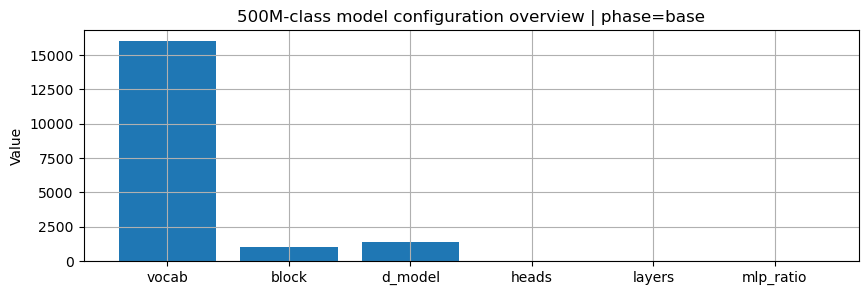

In [34]:
# ============================================================
# CELL 9: PHASE-AWARE EXPERIMENT CONFIGURATION
# ============================================================
# This cell defines:
# 1. the 500M-class model config
# 2. the training config
# 3. the active phase ("base" or "adapt")
# 4. the phase-specific token paths
# 5. grouped qualitative eval prompts
#
# Notes:
# - This version exports BOTH:
#     QUAL_EVAL_PROMPTS     -> grouped dict for training/eval
#     ALL_QUAL_PROMPTS      -> flattened list if needed later
# - It also exports phase_token_paths, train_path, val_path
# - It is aligned with the worker written in Cell 13
# ============================================================

require_globals("vocab_size", "block_size", "RUNS_DIR", "DATA_DIR", "SEED")

from dataclasses import dataclass, asdict
from pathlib import Path
import json

# ------------------------------------------------------------
# Active phase
# ------------------------------------------------------------
# Choose:
# - "base"  : broad language modeling phase
# - "adapt" : domain adaptation phase
ACTIVE_PHASE = "base"

# ------------------------------------------------------------
# Grouped qualitative eval prompts
# ------------------------------------------------------------
QUAL_EVAL_PROMPTS = {
    "generic": [
        "The future of science depends on",
        "In a well-designed system,",
        "History shows that",
    ],
    "technical": [
        "An attention head can",
        "Distributed training requires",
        "The KV cache stores",
    ],
    "domain": [
        "Africa can",
        "A just society requires",
        "Sustainable infrastructure depends on",
    ],
}

ALL_QUAL_PROMPTS = [p for group in QUAL_EVAL_PROMPTS.values() for p in group]

# ------------------------------------------------------------
# Rebuild phase_token_paths if missing
# ------------------------------------------------------------
PHASE_DATA_DIR = DATA_DIR / "phase_tokens"
PHASE_DATA_DIR.mkdir(parents=True, exist_ok=True)

base_train_tokens_path = PHASE_DATA_DIR / "base_train_tokens.npy"
base_val_tokens_path = PHASE_DATA_DIR / "base_val_tokens.npy"
adapt_train_tokens_path = PHASE_DATA_DIR / "adapt_train_tokens.npy"
adapt_val_tokens_path = PHASE_DATA_DIR / "adapt_val_tokens.npy"

required_phase_paths = [
    base_train_tokens_path,
    base_val_tokens_path,
    adapt_train_tokens_path,
    adapt_val_tokens_path,
]
missing_phase_paths = [p for p in required_phase_paths if not Path(p).exists()]
if missing_phase_paths:
    raise RuntimeError(
        "Missing phase token split files from CELL 8. Rerun CELL 8 first:\n"
        + "\n".join(f"- {p}" for p in missing_phase_paths)
    )

phase_token_paths = {
    "base": {
        "train": base_train_tokens_path,
        "val": base_val_tokens_path,
    },
    "adapt": {
        "train": adapt_train_tokens_path,
        "val": adapt_val_tokens_path,
    },
}

if ACTIVE_PHASE not in phase_token_paths:
    raise RuntimeError(
        f"ACTIVE_PHASE={ACTIVE_PHASE!r} is invalid. "
        f"Available phases: {list(phase_token_paths.keys())}"
    )

active_train_path = Path(phase_token_paths[ACTIVE_PHASE]["train"])
active_val_path = Path(phase_token_paths[ACTIVE_PHASE]["val"])

if not active_train_path.exists() or not active_val_path.exists():
    raise RuntimeError(
        "Active phase token files do not exist:\n"
        f"- train: {active_train_path}\n"
        f"- val:   {active_val_path}"
    )

# ------------------------------------------------------------
# Optional init checkpoint for adaptation
# ------------------------------------------------------------
base_run_dir = RUNS_DIR / "kb_500m_fsdp_base"
default_base_ckpt = base_run_dir / "checkpoint_latest.pt"

if ACTIVE_PHASE == "adapt" and default_base_ckpt.exists():
    init_from_checkpoint = str(default_base_ckpt)
else:
    init_from_checkpoint = None

# ------------------------------------------------------------
# Model config
# ------------------------------------------------------------
@dataclass
class ModelConfig:
    vocab_size: int = vocab_size
    block_size: int = block_size

    # ~500M-class
    d_model: int = 1408
    n_heads: int = 22
    n_layers: int = 20
    mlp_ratio: int = 4

    dropout: float = 0.10
    bias: bool = False
    tie_weights: bool = True

# ------------------------------------------------------------
# Train config
# ------------------------------------------------------------
@dataclass
class TrainConfig:
    seed: int = SEED

    use_bf16: bool = True
    grad_clip: float = 1.0
    weight_decay: float = 0.10

    micro_batch_size: int = 1
    grad_accum_steps: int = 8

    learning_rate: float = 3e-4
    min_lr_scale: float = 0.10
    warmup_steps: int = 100
    max_steps: int = 5000

    # More responsive notebook behavior
    log_interval: int = 1
    eval_interval: int = 50
    eval_batches: int = 10
    save_interval: int = 100

    # Qualitative generation should be rarer and cheaper
    qual_eval_interval: int = 200
    qual_max_new_tokens: int = 48
    qual_temperature: float = 0.7
    qual_top_k: int = 40

    num_data_workers: int = 2
    activation_checkpointing: bool = True

    phase_name: str = ACTIVE_PHASE
    run_name: str = f"kb_500m_fsdp_{ACTIVE_PHASE}"
    init_from_checkpoint: str | None = init_from_checkpoint

    # critical: worker expects this exact key
    eval_prompt_groups: dict = None

model_cfg = ModelConfig()
train_cfg = TrainConfig(eval_prompt_groups=QUAL_EVAL_PROMPTS)

RUN_DIR = RUNS_DIR / train_cfg.run_name
RUN_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Export generic names for downstream cells
# ------------------------------------------------------------
train_path = active_train_path
val_path = active_val_path

phase_summary = {
    "active_phase": ACTIVE_PHASE,
    "train_path": str(train_path),
    "val_path": str(val_path),
    "qual_eval_prompt_groups": QUAL_EVAL_PROMPTS,
    "phase_token_paths": {k: {kk: str(vv) for kk, vv in v.items()} for k, v in phase_token_paths.items()},
    "init_from_checkpoint": init_from_checkpoint,
}

print("Active phase:", ACTIVE_PHASE)
print("Train path  :", train_path)
print("Val path    :", val_path)
print("Init ckpt   :", init_from_checkpoint)

print("\nModel config:")
print(model_cfg)

print("\nTrain config:")
print(train_cfg)

print("\nRun dir:")
print(RUN_DIR)

fig, ax = plt.subplots(figsize=(10, 3))
labels = ["vocab", "block", "d_model", "heads", "layers", "mlp_ratio"]
values = [
    model_cfg.vocab_size,
    model_cfg.block_size,
    model_cfg.d_model,
    model_cfg.n_heads,
    model_cfg.n_layers,
    model_cfg.mlp_ratio,
]
ax.bar(labels, values)
ax.set_title(f"500M-class model configuration overview | phase={ACTIVE_PHASE}")
ax.set_ylabel("Value")
plt.show()

In [24]:
# ============================================================
# CELL 10: WRITE SHARED MODEL MODULE
# ============================================================
# Major upgrade:
# - richer per-head diagnostics
# - keep all previous dashboards compatible
# - preserve hidden-state capture
# ============================================================

require_globals("MODULE_DIR", "model_cfg", "train_cfg")

shared_module_path = MODULE_DIR / "kb_modeling_500m.py"

shared_module_code = r'''
import math
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F

@dataclass
class ModelConfig:
    vocab_size: int
    block_size: int
    d_model: int
    n_heads: int
    n_layers: int
    mlp_ratio: int
    dropout: float
    bias: bool
    tie_weights: bool = True

def count_parameters(module):
    return sum(p.numel() for p in module.parameters() if p.requires_grad)

class CausalSelfAttention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        assert cfg.d_model % cfg.n_heads == 0

        self.n_heads = cfg.n_heads
        self.d_model = cfg.d_model
        self.head_dim = cfg.d_model // cfg.n_heads
        self.scale = self.head_dim ** -0.5

        self.q_proj = nn.Linear(cfg.d_model, cfg.d_model, bias=cfg.bias)
        self.k_proj = nn.Linear(cfg.d_model, cfg.d_model, bias=cfg.bias)
        self.v_proj = nn.Linear(cfg.d_model, cfg.d_model, bias=cfg.bias)
        self.out_proj = nn.Linear(cfg.d_model, cfg.d_model, bias=cfg.bias)
        self.dropout = nn.Dropout(cfg.dropout)

        self.last_scores = None
        self.last_attn = None

        self.last_q_norm = None
        self.last_k_norm = None
        self.last_v_norm = None
        self.last_entropy = None

        self.last_q_norm_by_head = None
        self.last_k_norm_by_head = None
        self.last_v_norm_by_head = None
        self.last_entropy_by_head = None

        mask = torch.tril(torch.ones(cfg.block_size, cfg.block_size))
        self.register_buffer("mask", mask.view(1, 1, cfg.block_size, cfg.block_size), persistent=False)

    def forward(self, x, capture_diagnostics=False):
        B, T, C = x.shape

        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)

        q = q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        if capture_diagnostics:
            scores = (q @ k.transpose(-2, -1)) * self.scale
            scores = scores.masked_fill(self.mask[:, :, :T, :T] == 0, float("-inf"))
            attn = F.softmax(scores, dim=-1)
            attn = self.dropout(attn)

            out = attn @ v

            self.last_scores = scores.detach()
            self.last_attn = attn.detach()

            q_norm_by_head = q.detach().norm(dim=-1).mean(dim=(0, 2)).float().cpu()
            k_norm_by_head = k.detach().norm(dim=-1).mean(dim=(0, 2)).float().cpu()
            v_norm_by_head = v.detach().norm(dim=-1).mean(dim=(0, 2)).float().cpu()

            p = attn.detach().clamp_min(1e-9)
            ent = -(p * p.log()).sum(dim=-1)  # [B, H, T]
            entropy_by_head = ent.mean(dim=(0, 2)).float().cpu()

            self.last_q_norm_by_head = q_norm_by_head.tolist()
            self.last_k_norm_by_head = k_norm_by_head.tolist()
            self.last_v_norm_by_head = v_norm_by_head.tolist()
            self.last_entropy_by_head = entropy_by_head.tolist()

            self.last_q_norm = float(q_norm_by_head.mean().item())
            self.last_k_norm = float(k_norm_by_head.mean().item())
            self.last_v_norm = float(v_norm_by_head.mean().item())
            self.last_entropy = float(entropy_by_head.mean().item())
        else:
            out = F.scaled_dot_product_attention(
                q, k, v,
                attn_mask=None,
                dropout_p=self.dropout.p if self.training else 0.0,
                is_causal=True,
            )

        out = out.transpose(1, 2).contiguous().view(B, T, C)
        out = self.out_proj(out)
        return out

class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        hidden_dim = cfg.d_model * cfg.mlp_ratio
        self.fc1 = nn.Linear(cfg.d_model, hidden_dim, bias=cfg.bias)
        self.fc2 = nn.Linear(hidden_dim, cfg.d_model, bias=cfg.bias)
        self.dropout = nn.Dropout(cfg.dropout)

        self.last_hidden_norm = None
        self.last_output_norm = None

    def forward(self, x, capture_diagnostics=False):
        h = F.gelu(self.fc1(x))
        out = self.fc2(h)
        out = self.dropout(out)

        if capture_diagnostics:
            self.last_hidden_norm = h.detach().norm(dim=-1).mean().item()
            self.last_output_norm = out.detach().norm(dim=-1).mean().item()

        return out

class TransformerBlock(nn.Module):
    def __init__(self, cfg, layer_index):
        super().__init__()
        self.layer_index = layer_index

        self.ln1 = nn.LayerNorm(cfg.d_model)
        self.attn = CausalSelfAttention(cfg)

        self.ln2 = nn.LayerNorm(cfg.d_model)
        self.mlp = FeedForward(cfg)

        self.last_pre_attn_norm = None
        self.last_post_attn_norm = None
        self.last_post_mlp_norm = None
        self.last_output = None

    def forward(self, x, capture_diagnostics=False):
        if capture_diagnostics:
            self.last_pre_attn_norm = x.detach().norm(dim=-1).mean().item()

        x = x + self.attn(self.ln1(x), capture_diagnostics=capture_diagnostics)

        if capture_diagnostics:
            self.last_post_attn_norm = x.detach().norm(dim=-1).mean().item()

        x = x + self.mlp(self.ln2(x), capture_diagnostics=capture_diagnostics)

        if capture_diagnostics:
            self.last_post_mlp_norm = x.detach().norm(dim=-1).mean().item()
            self.last_output = x.detach()

        return x

class KBDecoderTransformer(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg

        self.token_embedding = nn.Embedding(cfg.vocab_size, cfg.d_model)
        self.position_embedding = nn.Embedding(cfg.block_size, cfg.d_model)

        self.blocks = nn.ModuleList([TransformerBlock(cfg, i) for i in range(cfg.n_layers)])
        self.ln_f = nn.LayerNorm(cfg.d_model)
        self.head = nn.Linear(cfg.d_model, cfg.vocab_size, bias=False)

        if cfg.tie_weights:
            self.head.weight = self.token_embedding.weight

        self.last_hidden_states = []
        self.last_logits = None

    def forward(self, idx, targets=None, capture_hidden_states=False, capture_diagnostics=False):
        B, T = idx.shape
        assert T <= self.cfg.block_size, "Sequence length exceeds configured block_size."

        pos = torch.arange(T, device=idx.device)
        x = self.token_embedding(idx) + self.position_embedding(pos)[None, :, :]

        hidden_states = []
        for block in self.blocks:
            x = block(x, capture_diagnostics=capture_diagnostics)
            if capture_hidden_states:
                hidden_states.append(x.detach())

        x = self.ln_f(x)
        logits = self.head(x)

        self.last_hidden_states = hidden_states
        self.last_logits = logits.detach()

        loss = None
        if targets is not None:
            B2, T2, V = logits.shape
            loss = F.cross_entropy(logits.view(B2 * T2, V), targets.view(B2 * T2))

        return logits, loss

def estimate_parameter_count(cfg):
    d = cfg.d_model
    hidden = d * cfg.mlp_ratio

    total = cfg.vocab_size * d + cfg.block_size * d
    per_layer = 4 * d * d + 2 * d * hidden + 4 * d
    total += cfg.n_layers * per_layer
    total += 2 * d

    if not cfg.tie_weights:
        total += cfg.vocab_size * d

    return total
'''

shared_module_path.write_text(shared_module_code, encoding="utf-8")
print("Wrote shared module to:", shared_module_path)

Wrote shared module to: /home/b/bl/bluetopazzz/artifacts_500m_kb/modules/kb_modeling_500m.py


Estimated parameter count: 499,876,608


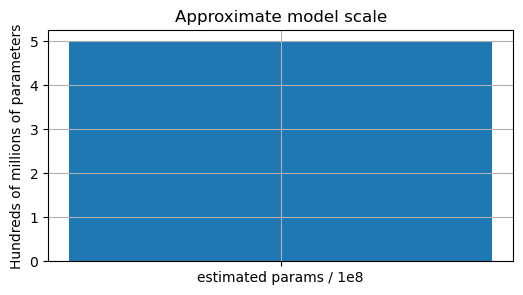

In [25]:
# ============================================================
# CELL 11: IMPORT SHARED MODEL MODULE AND VERIFY IT
# ============================================================
# This cell imports the shared model module and checks that the
# parameter estimate is in the expected ~500M-class range.
#
# Why this matters:
# - We want the notebook and worker to agree on architecture
# - We want to catch import issues before launching torchrun
# ============================================================

require_globals("shared_module_path", "model_cfg")

import sys
sys.path.insert(0, str(MODULE_DIR))

from kb_modeling_500m import (
    ModelConfig as SharedModelConfig,
    KBDecoderTransformer,
    count_parameters,
    estimate_parameter_count,
)

shared_model_cfg = SharedModelConfig(**asdict(model_cfg))

estimated_params = estimate_parameter_count(shared_model_cfg)
print(f"Estimated parameter count: {estimated_params:,}")

if estimated_params < 400_000_000:
    print("WARNING: Parameter estimate is lower than expected for a 500M-class run.")
if estimated_params > 650_000_000:
    print("WARNING: Parameter estimate is higher than expected for a 500M-class run.")

plt.figure(figsize=(6, 3))
plt.bar(["estimated params / 1e8"], [estimated_params / 1e8])
plt.title("Approximate model scale")
plt.ylabel("Hundreds of millions of parameters")
plt.show()

In [26]:
# ============================================================
# CELL 12: TINY LOCAL SMOKE TEST
# ============================================================
# This cell does not instantiate the full 500M model yet.
# Instead, it verifies that the shared model code works with a
# much smaller configuration on a single device.
#
# Why this cell exists:
# - It catches model-code bugs cheaply
# - It avoids spending GPU memory on the full model before
#   basic correctness is confirmed
# ============================================================

require_globals("KBDecoderTransformer", "SharedModelConfig", "vocab_size", "block_size")

tiny_cfg = SharedModelConfig(
    vocab_size=vocab_size,
    block_size=min(block_size, 128),
    d_model=128,
    n_heads=8,
    n_layers=4,
    mlp_ratio=4,
    dropout=0.1,
    bias=False,
    tie_weights=True,
)

tiny_model = KBDecoderTransformer(tiny_cfg).to("cuda" if torch.cuda.is_available() else "cpu")
tiny_x = torch.randint(0, tiny_cfg.vocab_size, (2, tiny_cfg.block_size), device=next(tiny_model.parameters()).device)
tiny_y = torch.randint(0, tiny_cfg.vocab_size, (2, tiny_cfg.block_size), device=next(tiny_model.parameters()).device)

tiny_logits, tiny_loss = tiny_model(
    tiny_x,
    tiny_y,
    capture_hidden_states=True,
    capture_diagnostics=True,
)

print("Tiny model forward-pass succeeded.")
print("Tiny logits shape:", tuple(tiny_logits.shape))
print("Tiny loss:", float(tiny_loss))

# Clean up aggressively
del tiny_model, tiny_x, tiny_y, tiny_logits, tiny_loss
torch.cuda.empty_cache()
gc.collect()

Tiny model forward-pass succeeded.
Tiny logits shape: (2, 128, 16000)
Tiny loss: 86.0257797241211


35752

In [45]:
# ============================================================
# CELL 13: WRITE PHASE-AWARE DISTRIBUTED FSDP WORKER
# ============================================================
# This refactor removes in-worker qualitative generation.
#
# Why:
# - your crash was a distributed/NCCL timeout after training was
#   otherwise progressing well
# - text generation inside the worker is the riskiest non-essential
#   operation during distributed training
# - training-time dashboards, val loss, checkpoints, and resume
#   are all preserved
#
# What stays:
# - train/val logging
# - checkpoint save/load
# - resume from latest checkpoint
# - optional init-from-checkpoint for adapt phase
#
# What is removed from the worker:
# - SentencePiece loading
# - qualitative sample generation
# - qual_samples.jsonl writing
# ============================================================

require_globals(
    "MODULE_DIR", "RUN_DIR", "train_path", "val_path",
    "model_cfg", "train_cfg"
)

worker_script_path = MODULE_DIR / f"train_worker_fsdp_500m_{train_cfg.phase_name}.py"

# IMPORTANT:
# Use repr(...) / asdict(...) so Python literals are written,
# not json.dumps(...), which would emit true/false/null.
model_cfg_py = repr(asdict(model_cfg))
train_cfg_py = repr(asdict(train_cfg))

worker_script_code = f"""
import os
import gc
import json
import math
import time
import random
from pathlib import Path

import numpy as np
import torch
import torch.distributed as dist

from torch.distributed.fsdp import (
    FullyShardedDataParallel as FSDP,
    ShardingStrategy,
    MixedPrecision,
    StateDictType,
    FullStateDictConfig,
)
from torch.distributed.fsdp.wrap import transformer_auto_wrap_policy
from torch.distributed.algorithms._checkpoint.checkpoint_wrapper import (
    checkpoint_wrapper,
    CheckpointImpl,
    apply_activation_checkpointing,
)
from functools import partial

from kb_modeling_500m import ModelConfig, KBDecoderTransformer, TransformerBlock

TRAIN_TOKENS_PATH = r"{str(train_path)}"
VAL_TOKENS_PATH   = r"{str(val_path)}"
RUN_DIR           = Path(r"{str(RUN_DIR)}")
RUN_DIR.mkdir(parents=True, exist_ok=True)

METRICS_PATH      = RUN_DIR / "metrics.jsonl"
LATEST_CKPT_PATH  = RUN_DIR / "checkpoint_latest.pt"
STATE_JSON_PATH   = RUN_DIR / "run_state.json"

MODEL_CFG_DICT = {model_cfg_py}
TRAIN_CFG_DICT = {train_cfg_py}

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def setup_distributed():
    local_rank = int(os.environ["LOCAL_RANK"])
    torch.cuda.set_device(local_rank)
    dist.init_process_group("nccl")
    rank = dist.get_rank()
    world_size = dist.get_world_size()
    return rank, world_size, local_rank

def cleanup():
    if dist.is_initialized():
        dist.destroy_process_group()

def get_lr(step, cfg):
    if step < cfg["warmup_steps"]:
        return cfg["learning_rate"] * (step + 1) / max(1, cfg["warmup_steps"])

    progress = (step - cfg["warmup_steps"]) / max(1, (cfg["max_steps"] - cfg["warmup_steps"]))
    progress = min(max(progress, 0.0), 1.0)

    cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
    min_lr = cfg["learning_rate"] * cfg["min_lr_scale"]
    return min_lr + cosine * (cfg["learning_rate"] - min_lr)

def append_jsonl(path, record):
    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(record, ensure_ascii=False) + "\\n")

def load_tokens(path):
    arr = np.load(path, mmap_mode="r")
    if len(arr) <= MODEL_CFG_DICT["block_size"] + 1:
        raise RuntimeError(f"Token stream too short in {{path}} for block_size.")
    return arr

def sample_batch(tokens, batch_size, block_size, device):
    max_start = len(tokens) - block_size - 1
    starts = np.random.randint(0, max_start, size=batch_size)

    x = np.stack([tokens[s:s+block_size] for s in starts]).astype(np.int64)
    y = np.stack([tokens[s+1:s+block_size+1] for s in starts]).astype(np.int64)

    x = torch.from_numpy(x).to(device, non_blocking=True)
    y = torch.from_numpy(y).to(device, non_blocking=True)
    return x, y

def evaluate(model, val_tokens, device, rank, world_size):
    model.eval()
    losses = []

    with torch.no_grad():
        for _ in range(TRAIN_CFG_DICT["eval_batches"]):
            x, y = sample_batch(
                val_tokens,
                TRAIN_CFG_DICT["micro_batch_size"],
                MODEL_CFG_DICT["block_size"],
                device,
            )
            _, loss = model(x, y)
            losses.append(loss.detach())

    loss_tensor = torch.stack(losses).mean()
    dist.all_reduce(loss_tensor, op=dist.ReduceOp.SUM)
    loss_tensor = loss_tensor / world_size

    model.train()
    return float(loss_tensor.item())

def get_grad_norm(model):
    total_sq = 0.0
    for p in model.parameters():
        if p.grad is not None:
            total_sq += p.grad.detach().pow(2).sum().item()
    return math.sqrt(total_sq)

def apply_activation_ckpt(model):
    if not TRAIN_CFG_DICT["activation_checkpointing"]:
        return

    def check_fn(submodule):
        return isinstance(submodule, TransformerBlock)

    wrapper = lambda m: checkpoint_wrapper(
        m,
        checkpoint_impl=CheckpointImpl.NO_REENTRANT
    )

    apply_activation_checkpointing(
        model,
        checkpoint_wrapper_fn=wrapper,
        check_fn=check_fn,
    )

def save_checkpoint(model, optimizer, step, rank, local_rank):
    dist.barrier(device_ids=[local_rank])

    state_cfg = FullStateDictConfig(offload_to_cpu=True, rank0_only=True)
    with FSDP.state_dict_type(model, StateDictType.FULL_STATE_DICT, state_cfg):
        model_state = model.state_dict()

    full_optim_state = FSDP.full_optim_state_dict(model, optimizer)

    if rank == 0:
        ckpt = {{
            "model_state_dict": model_state,
            "optimizer_state_dict": full_optim_state,
            "step": step,
            "model_cfg": MODEL_CFG_DICT,
            "train_cfg": TRAIN_CFG_DICT,
        }}
        torch.save(ckpt, LATEST_CKPT_PATH)

        with open(STATE_JSON_PATH, "w", encoding="utf-8") as f:
            json.dump({{
                "latest_checkpoint": str(LATEST_CKPT_PATH),
                "last_completed_step": step,
                "phase_name": TRAIN_CFG_DICT["phase_name"],
                "timestamp": time.time(),
            }}, f, indent=2)

    dist.barrier(device_ids=[local_rank])

def load_model_state_only(model, ckpt_path, local_rank):
    ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    with FSDP.state_dict_type(
        model,
        StateDictType.FULL_STATE_DICT,
        FullStateDictConfig(offload_to_cpu=True, rank0_only=False),
    ):
        model.load_state_dict(ckpt["model_state_dict"])
    dist.barrier(device_ids=[local_rank])
    return ckpt

def maybe_initialize_or_resume(model, optimizer, rank, local_rank):
    start_step = 0

    if LATEST_CKPT_PATH.exists():
        ckpt = load_model_state_only(model, LATEST_CKPT_PATH, local_rank)

        full_osd = ckpt["optimizer_state_dict"] if rank == 0 else None
        sharded_osd = FSDP.scatter_full_optim_state_dict(full_osd, model)
        optimizer.load_state_dict(sharded_osd)

        start_step = int(ckpt.get("step", 0)) + 1
        if rank == 0:
            print(f"[resume] Loaded model + optimizer checkpoint from step {{start_step - 1}}")
        return start_step

    init_ckpt = TRAIN_CFG_DICT.get("init_from_checkpoint", None)
    if init_ckpt is not None and str(init_ckpt).strip():
        init_ckpt_path = Path(init_ckpt)
        if init_ckpt_path.exists():
            _ = load_model_state_only(model, init_ckpt_path, local_rank)
            if rank == 0:
                print(f"[init] Loaded model weights from {{init_ckpt_path}}")
                print("[init] Starting new phase with fresh optimizer state at step 0.")
        else:
            if rank == 0:
                print(f"[init-warning] init_from_checkpoint not found: {{init_ckpt_path}}")

    return start_step

def main():
    rank, world_size, local_rank = setup_distributed()

    cfg = ModelConfig(**MODEL_CFG_DICT)
    train_cfg = TRAIN_CFG_DICT
    device = torch.device("cuda", local_rank)

    set_seed(train_cfg["seed"] + rank)

    if rank == 0:
        print("Starting 3-GPU FSDP training worker")
        print("Run dir:", RUN_DIR)
        print("Phase:", train_cfg["phase_name"])
        print("Visible CUDA device for this rank:", local_rank)

    train_tokens = load_tokens(TRAIN_TOKENS_PATH)
    val_tokens = load_tokens(VAL_TOKENS_PATH)

    model = KBDecoderTransformer(cfg)
    apply_activation_ckpt(model)

    mp_policy = MixedPrecision(
        param_dtype=torch.bfloat16 if train_cfg["use_bf16"] else torch.float32,
        reduce_dtype=torch.bfloat16 if train_cfg["use_bf16"] else torch.float32,
        buffer_dtype=torch.bfloat16 if train_cfg["use_bf16"] else torch.float32,
    )

    auto_wrap_policy = partial(
        transformer_auto_wrap_policy,
        transformer_layer_cls={{TransformerBlock}},
    )

    model = FSDP(
        model,
        auto_wrap_policy=auto_wrap_policy,
        mixed_precision=mp_policy,
        sharding_strategy=ShardingStrategy.FULL_SHARD,
        device_id=torch.cuda.current_device(),
        forward_prefetch=True,
        limit_all_gathers=True,
        use_orig_params=True,
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=train_cfg["learning_rate"],
        weight_decay=train_cfg["weight_decay"],
        betas=(0.9, 0.95),
    )

    start_step = maybe_initialize_or_resume(model, optimizer, rank, local_rank)

    model.train()
    start_wall = time.time()

    for step in range(start_step, train_cfg["max_steps"]):
        lr = get_lr(step, train_cfg)
        for pg in optimizer.param_groups:
            pg["lr"] = lr

        optimizer.zero_grad(set_to_none=True)

        total_loss = 0.0
        for _ in range(train_cfg["grad_accum_steps"]):
            x, y = sample_batch(
                train_tokens,
                train_cfg["micro_batch_size"],
                cfg.block_size,
                device,
            )

            _, loss = model(x, y)
            loss = loss / train_cfg["grad_accum_steps"]
            loss.backward()
            total_loss += float(loss.detach().item())

        torch.nn.utils.clip_grad_norm_(model.parameters(), train_cfg["grad_clip"])
        grad_norm = get_grad_norm(model)
        optimizer.step()

        train_loss = total_loss

        do_log = (step % train_cfg["log_interval"] == 0)
        do_eval = (step % train_cfg["eval_interval"] == 0)
        do_save = (step % train_cfg["save_interval"] == 0 and step > start_step)

        val_loss = None
        if do_eval:
            val_loss = evaluate(model, val_tokens, device, rank, world_size)

        if do_log:
            train_loss_tensor = torch.tensor([train_loss], device=device)
            grad_norm_tensor = torch.tensor([grad_norm], device=device)

            dist.all_reduce(train_loss_tensor, op=dist.ReduceOp.SUM)
            dist.all_reduce(grad_norm_tensor, op=dist.ReduceOp.SUM)

            train_loss_tensor = train_loss_tensor / world_size
            grad_norm_tensor = grad_norm_tensor / world_size

            max_alloc = torch.cuda.max_memory_allocated(device) / 1024**3
            max_reserved = torch.cuda.max_memory_reserved(device) / 1024**3

            if rank == 0:
                elapsed = time.time() - start_wall
                toks = (step - start_step + 1) * train_cfg["micro_batch_size"] * cfg.block_size * world_size * train_cfg["grad_accum_steps"]
                toks_per_sec = toks / max(elapsed, 1e-6)

                record = {{
                    "step": step,
                    "phase_name": train_cfg["phase_name"],
                    "train_loss": float(train_loss_tensor.item()),
                    "val_loss": float(val_loss) if val_loss is not None else None,
                    "grad_norm": float(grad_norm_tensor.item()),
                    "lr": float(lr),
                    "tokens_per_sec": float(toks_per_sec),
                    "rank0_max_alloc_gib": float(max_alloc),
                    "rank0_max_reserved_gib": float(max_reserved),
                    "timestamp": time.time(),
                }}
                append_jsonl(METRICS_PATH, record)

                print(
                    f"[step={{step}}] "
                    f"train={{record['train_loss']:.4f}} "
                    f"val={{record['val_loss'] if record['val_loss'] is not None else 'NA'}} "
                    f"grad={{record['grad_norm']:.4f}} "
                    f"lr={{record['lr']:.6e}} "
                    f"tok/s={{record['tokens_per_sec']:.1f}} "
                    f"alloc_gib={{record['rank0_max_alloc_gib']:.2f}} "
                    f"reserved_gib={{record['rank0_max_reserved_gib']:.2f}}"
                )

        if do_save:
            save_checkpoint(model, optimizer, step, rank, local_rank)

    save_checkpoint(model, optimizer, train_cfg["max_steps"] - 1, rank, local_rank)

    if rank == 0:
        print("Training finished successfully.")

    cleanup()
    gc.collect()

if __name__ == "__main__":
    main()
"""

worker_script_path.write_text(worker_script_code, encoding="utf-8")
print("Wrote worker script to:", worker_script_path)

Wrote worker script to: /home/b/bl/bluetopazzz/artifacts_500m_kb/modules/train_worker_fsdp_500m_base.py


In [46]:
# ============================================================
# CELL 14: WORKER / FILE PREFLIGHT
# ============================================================

require_globals("train_path", "val_path", "shared_module_path", "worker_script_path", "RUN_DIR", "model_path")

required_paths = [
    train_path,
    val_path,
    shared_module_path,
    worker_script_path,
    model_path,
]

missing_paths = [p for p in required_paths if not Path(p).exists()]
if missing_paths:
    raise RuntimeError(
        "Missing required files before launch:\n" + "\n".join(f"- {p}" for p in missing_paths)
    )

test_file = RUN_DIR / "_write_test.txt"
test_file.write_text("ok", encoding="utf-8")
test_file.unlink()

print("All required training files exist and RUN_DIR is writable.")
for p in required_paths:
    print("-", p)

All required training files exist and RUN_DIR is writable.
- /home/b/bl/bluetopazzz/artifacts_500m_kb/data/phase_tokens/base_train_tokens.npy
- /home/b/bl/bluetopazzz/artifacts_500m_kb/data/phase_tokens/base_val_tokens.npy
- /home/b/bl/bluetopazzz/artifacts_500m_kb/modules/kb_modeling_500m.py
- /home/b/bl/bluetopazzz/artifacts_500m_kb/modules/train_worker_fsdp_500m_base.py
- /home/b/bl/bluetopazzz/artifacts_500m_kb/tokenizer/kb_spm_16000.model


In [ ]:
# ============================================================
# CELL 15: OPTIONAL FULL-MODEL CONSTRUCTION CHECK
# ============================================================
# This cell attempts to instantiate the full model on a single
# GPU and run a tiny forward pass.
#
# Why optional:
# - It consumes real GPU memory
# - It is extremely useful for catching architecture mistakes
#   before a distributed launch
#
# If you are very memory-constrained, you can skip this cell.
# ============================================================

require_globals("KBDecoderTransformer", "shared_model_cfg")

do_full_model_check = True

if do_full_model_check:
    try:
        device0 = torch.device("cuda:0")
        model_check = KBDecoderTransformer(shared_model_cfg).to(device0, dtype=torch.bfloat16)

        # Tiny batch just to verify shape flow
        x = torch.randint(0, shared_model_cfg.vocab_size, (1, 32), device=device0)
        y = torch.randint(0, shared_model_cfg.vocab_size, (1, 32), device=device0)

        logits, loss = model_check(x, y, capture_hidden_states=False, capture_diagnostics=False)

        print("Full-model local construction check succeeded.")
        print("Logits shape:", tuple(logits.shape))
        print("Loss:", float(loss))

        del model_check, x, y, logits, loss
        torch.cuda.empty_cache()
        gc.collect()
    except Exception as e:
        raise RuntimeError(f"Full-model local construction check failed: {repr(e)}")
else:
    print("Skipped full-model construction check.")

Full-model local construction check succeeded.
Logits shape: (1, 32, 16000)
Loss: 764.0


In [ ]:
# ============================================================
# CELL 16: RUN METADATA AND RESUME DETECTION
# ============================================================

require_globals("RUN_DIR", "worker_script_path", "MODULE_DIR", "ACTIVE_PHASE", "train_cfg")

latest_ckpt_path = RUN_DIR / "checkpoint_latest.pt"
metrics_path = RUN_DIR / "metrics.jsonl"
samples_path = RUN_DIR / "qual_samples.jsonl"
worker_log_path = RUN_DIR / "worker_stdout.log"
state_json_path = RUN_DIR / "run_state.json"

resume_available = latest_ckpt_path.exists()
last_checkpointed_step = None
state_info = None

if state_json_path.exists():
    with open(state_json_path, "r", encoding="utf-8") as f:
        state_info = json.load(f)
    last_checkpointed_step = state_info.get("last_completed_step", None)

print("Active phase:", ACTIVE_PHASE)
print("Run directory:", RUN_DIR)
print("Latest checkpoint exists:", resume_available)
print("Last checkpointed step :", last_checkpointed_step)
print("Metrics path:", metrics_path)
print("Qual sample path:", samples_path)
print("Worker log path:", worker_log_path)

if state_info is not None:
    print("\nState info:")
    print(json.dumps(state_info, indent=2)[:1200])

launch_cmd = [
    "torchrun",
    "--standalone",
    "--nproc_per_node=3",
    str(worker_script_path),
]

print("\nLaunch command preview:")
print(" ".join(shlex.quote(part) for part in launch_cmd))

Active phase: base
Run directory: /home/b/bl/bluetopazzz/artifacts_500m_kb/runs/kb_500m_fsdp_base
Latest checkpoint exists: True
Last checkpointed step : 900
Metrics path: /home/b/bl/bluetopazzz/artifacts_500m_kb/runs/kb_500m_fsdp_base/metrics.jsonl
Qual sample path: /home/b/bl/bluetopazzz/artifacts_500m_kb/runs/kb_500m_fsdp_base/qual_samples.jsonl
Worker log path: /home/b/bl/bluetopazzz/artifacts_500m_kb/runs/kb_500m_fsdp_base/worker_stdout.log

State info:
{
  "latest_checkpoint": "/home/b/bl/bluetopazzz/artifacts_500m_kb/runs/kb_500m_fsdp_base/checkpoint_latest.pt",
  "last_completed_step": 900,
  "phase_name": "base",
  "timestamp": 1775934872.9363801
}

Launch command preview:
torchrun --standalone --nproc_per_node=3 /home/b/bl/bluetopazzz/artifacts_500m_kb/modules/train_worker_fsdp_500m_base.py


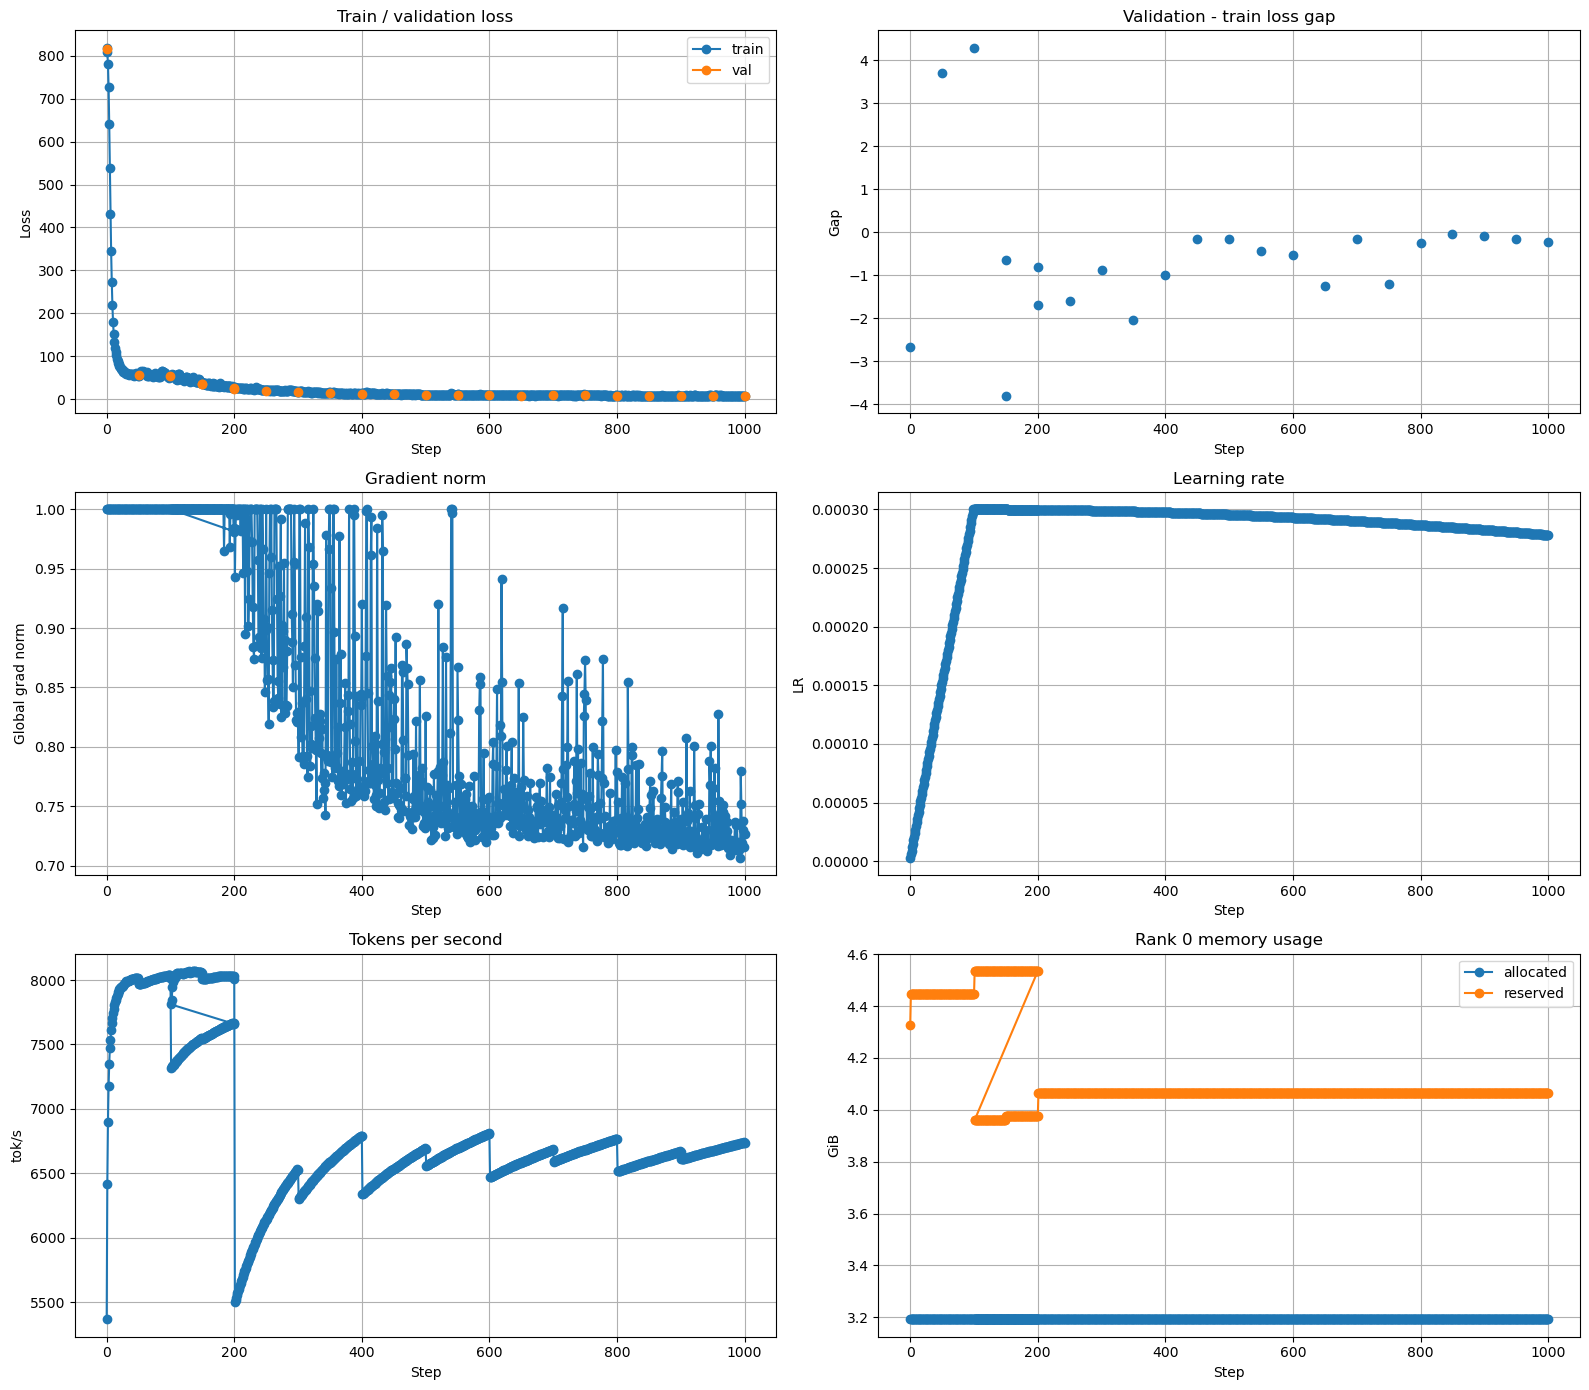

Last recorded step: 1000
Last train loss   : 7.6068
Last val loss     : 7.375
Last grad norm    : 0.7262
Last tokens/sec   : 6739.4
Seconds since new step logged: 6.1

Recent worker output:

W0411 12:31:45.616000 2810151 mamba/envs/torch-gpu/lib/python3.11/site-packages/torch/distributed/run.py:793] 
W0411 12:31:45.616000 2810151 mamba/envs/torch-gpu/lib/python3.11/site-packages/torch/distributed/run.py:793] *****************************************
W0411 12:31:45.616000 2810151 mamba/envs/torch-gpu/lib/python3.11/site-packages/torch/distributed/run.py:793] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0411 12:31:45.616000 2810151 mamba/envs/torch-gpu/lib/python3.11/site-packages/torch/distributed/run.py:793] *****************************************
Starting 3-GPU FSDP training worker

Worker exited with code: 1

Last line

In [54]:
# ============================================================
# CELL 17: TRAINING LAUNCHER WITH LIVE DASHBOARD
# ============================================================
# Improvements:
# - preserves logs
# - shows latest qualitative samples if available
# - refreshes even when no new steps arrive
# - explains idle periods better
# ============================================================

require_globals("launch_cmd", "metrics_path", "worker_log_path", "MODULE_DIR", "samples_path")

refresh_seconds = 3.0

env = os.environ.copy()
env["PYTHONPATH"] = str(MODULE_DIR) + os.pathsep + env.get("PYTHONPATH", "")

if not worker_log_path.exists():
    worker_log_path.write_text("", encoding="utf-8")

def load_metrics_jsonl(path):
    if not path.exists():
        return []
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    rows.append(json.loads(line))
                except json.JSONDecodeError:
                    pass
    return rows

def tail_file(path, n=80):
    if not path.exists():
        return []
    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()
    return [line.rstrip("\n") for line in lines[-n:]]

def load_recent_samples(path):
    if not path.exists():
        return None
    last_line = None
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                last_line = line
    if last_line is None:
        return None
    try:
        return json.loads(last_line)
    except json.JSONDecodeError:
        return None

print("Launching worker process...")
print(" ".join(shlex.quote(part) for part in launch_cmd))

proc = subprocess.Popen(
    launch_cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
    env=env,
)

recent_lines = []
last_seen_step = None
last_step_change_time = time.time()

try:
    last_refresh = 0.0

    while True:
        ready, _, _ = select.select([proc.stdout], [], [], 0.1)
        if ready:
            line = proc.stdout.readline()
            if line:
                recent_lines.append(line.rstrip("\n"))
                recent_lines = recent_lines[-80:]
                with open(worker_log_path, "a", encoding="utf-8") as f:
                    f.write(line)

        now = time.time()
        if now - last_refresh >= refresh_seconds:
            last_refresh = now
            rows = load_metrics_jsonl(metrics_path)
            latest_samples = load_recent_samples(samples_path)

            clear_output(wait=True)

            if rows:
                steps = [r["step"] for r in rows]
                train_losses = [r["train_loss"] for r in rows]
                val_losses = [r["val_loss"] if r["val_loss"] is not None else np.nan for r in rows]
                grad_norms = [r["grad_norm"] for r in rows]
                lrs = [r["lr"] for r in rows]
                toks = [r["tokens_per_sec"] for r in rows]
                allocs = [r["rank0_max_alloc_gib"] for r in rows]
                reserves = [r["rank0_max_reserved_gib"] for r in rows]

                if last_seen_step != steps[-1]:
                    last_seen_step = steps[-1]
                    last_step_change_time = now

                fig, axes = plt.subplots(3, 2, figsize=(16, 14))

                axes[0, 0].plot(steps, train_losses, marker="o", label="train")
                axes[0, 0].plot(steps, val_losses, marker="o", label="val")
                axes[0, 0].set_title("Train / validation loss")
                axes[0, 0].set_xlabel("Step")
                axes[0, 0].set_ylabel("Loss")
                axes[0, 0].legend()

                gap = np.array(val_losses) - np.array(train_losses)
                axes[0, 1].plot(steps, gap, marker="o")
                axes[0, 1].set_title("Validation - train loss gap")
                axes[0, 1].set_xlabel("Step")
                axes[0, 1].set_ylabel("Gap")

                axes[1, 0].plot(steps, grad_norms, marker="o")
                axes[1, 0].set_title("Gradient norm")
                axes[1, 0].set_xlabel("Step")
                axes[1, 0].set_ylabel("Global grad norm")

                axes[1, 1].plot(steps, lrs, marker="o")
                axes[1, 1].set_title("Learning rate")
                axes[1, 1].set_xlabel("Step")
                axes[1, 1].set_ylabel("LR")

                axes[2, 0].plot(steps, toks, marker="o")
                axes[2, 0].set_title("Tokens per second")
                axes[2, 0].set_xlabel("Step")
                axes[2, 0].set_ylabel("tok/s")

                axes[2, 1].plot(steps, allocs, marker="o", label="allocated")
                axes[2, 1].plot(steps, reserves, marker="o", label="reserved")
                axes[2, 1].set_title("Rank 0 memory usage")
                axes[2, 1].set_xlabel("Step")
                axes[2, 1].set_ylabel("GiB")
                axes[2, 1].legend()

                plt.tight_layout()
                plt.show()

                print(f"Last recorded step: {steps[-1]}")
                print(f"Last train loss   : {train_losses[-1]:.4f}")
                print(f"Last val loss     : {val_losses[-1] if not np.isnan(val_losses[-1]) else 'NA'}")
                print(f"Last grad norm    : {grad_norms[-1]:.4f}")
                print(f"Last tokens/sec   : {toks[-1]:.1f}")
                print(f"Seconds since new step logged: {now - last_step_change_time:.1f}")
            else:
                print("No metrics recorded yet. Waiting for first log record...")

            if latest_samples is not None:
                print("\nLatest qualitative samples:")
                print(f"step={latest_samples['step']} phase={latest_samples.get('phase_name', 'unknown')}")
                for group_name, group_samples in latest_samples["samples"].items():
                    print(f"\n[{group_name}]")
                    for item in group_samples[:2]:
                        print("-" * 80)
                        print("PROMPT :", repr(item["prompt"]))
                        print("SAMPLE :", item["sample"][:600])

            print("\nRecent worker output:\n")
            print("\n".join(recent_lines[-25:]))

        ret = proc.poll()
        if ret is not None:
            remaining = proc.stdout.read()
            if remaining:
                for line in remaining.splitlines():
                    recent_lines.append(line)
                    recent_lines = recent_lines[-80:]
                    with open(worker_log_path, "a", encoding="utf-8") as f:
                        f.write(line + "\n")

            print(f"\nWorker exited with code: {ret}")

            if ret != 0:
                print("\nLast lines from worker log:\n")
                print("\n".join(tail_file(worker_log_path, n=160)))

            break

except KeyboardInterrupt:
    print("\nKeyboardInterrupt received. Terminating worker process...")
    proc.terminate()
    try:
        proc.wait(timeout=20)
    except subprocess.TimeoutExpired:
        print("Worker did not exit promptly; killing it.")
        proc.kill()
        proc.wait()

    print("Worker stopped. Existing checkpoints remain on disk and can be resumed.")

In [ ]:
# ============================================================
# CELL 18: LOAD LATEST CHECKPOINT INTO NOTEBOOK MODEL
# ============================================================

require_globals("latest_ckpt_path", "shared_model_cfg", "KBDecoderTransformer")

if not latest_ckpt_path.exists():
    raise RuntimeError(
        "No checkpoint_latest.pt found. Run training first or verify RUN_DIR."
    )

analysis_device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

analysis_model = KBDecoderTransformer(shared_model_cfg).to(analysis_device, dtype=torch.bfloat16)
ckpt = torch.load(latest_ckpt_path, map_location="cpu", weights_only=False)

analysis_model.load_state_dict(ckpt["model_state_dict"])
analysis_model.eval()

ckpt_train_cfg = ckpt.get("train_cfg", {})
ckpt_model_cfg = ckpt.get("model_cfg", {})

print("Loaded checkpoint into analysis model.")
print("Checkpoint step:", ckpt.get("step", "unknown"))
print("Analysis device:", analysis_device)
print("Phase name:", ckpt_train_cfg.get("phase_name", "unknown"))
print("Run name  :", ckpt_train_cfg.get("run_name", "unknown"))
print("Block size:", ckpt_model_cfg.get("block_size", shared_model_cfg.block_size))

In [ ]:
# ============================================================
# CELL 19: GENERATION HELPER
# ============================================================
# Upgrades:
# - repetition penalty
# - optional top-p
# - EOS-aware early stopping
# ============================================================

require_globals("analysis_model", "encode", "decode", "shared_model_cfg", "analysis_device", "EOS_ID")

@torch.no_grad()
def generate(
    model,
    prompt,
    max_new_tokens=200,
    temperature=0.8,
    top_k=40,
    top_p=None,
    repetition_penalty=1.05,
    stop_on_eos=True,
):
    model.eval()

    ids = encode(prompt)
    x = torch.tensor(ids, dtype=torch.long, device=analysis_device).unsqueeze(0)

    for _ in range(max_new_tokens):
        x_cond = x[:, -shared_model_cfg.block_size:]
        logits, _ = model(x_cond, capture_hidden_states=False, capture_diagnostics=False)
        logits = logits[:, -1, :]

        if repetition_penalty is not None and repetition_penalty > 1.0:
            unique_recent = torch.unique(x_cond[0])
            logits[0, unique_recent] /= repetition_penalty

        logits = logits / max(temperature, 1e-5)

        if top_k is not None:
            k = min(top_k, logits.shape[-1])
            top_vals, top_idx = torch.topk(logits, k=k)
            mask = torch.full_like(logits, float("-inf"))
            mask.scatter_(1, top_idx, top_vals)
            logits = mask

        if top_p is not None:
            sorted_logits, sorted_indices = torch.sort(logits, descending=True)
            sorted_probs = torch.softmax(sorted_logits, dim=-1)
            cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

            remove_mask = cumulative_probs > top_p
            remove_mask[..., 1:] = remove_mask[..., :-1].clone()
            remove_mask[..., 0] = False

            sorted_logits[remove_mask] = float("-inf")
            logits = torch.full_like(logits, float("-inf"))
            logits.scatter_(1, sorted_indices, sorted_logits)

        probs = F.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)

        x = torch.cat([x, next_id], dim=1)

        if stop_on_eos and int(next_id.item()) == EOS_ID:
            break

    return decode(x[0].tolist())

print(generate(analysis_model, "Africa can", max_new_tokens=120, temperature=0.75, top_k=40, repetition_penalty=1.08))

In [ ]:
# ============================================================
# CELL 20: TRAINING SUMMARY DASHBOARD
# ============================================================

require_globals("metrics_path")

def load_metrics_rows(path):
    rows = []
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    rows.append(json.loads(line))
    return rows

rows = load_metrics_rows(metrics_path)
if not rows:
    raise RuntimeError("No metrics found yet. Run training before viewing the dashboard.")

steps = [r["step"] for r in rows]
train_losses = [r["train_loss"] for r in rows]
val_losses = [r["val_loss"] if r["val_loss"] is not None else np.nan for r in rows]
grad_norms = [r["grad_norm"] for r in rows]
lrs = [r["lr"] for r in rows]
toks = [r["tokens_per_sec"] for r in rows]
allocs = [r["rank0_max_alloc_gib"] for r in rows]
reserves = [r["rank0_max_reserved_gib"] for r in rows]
phase_names = [r.get("phase_name", "unknown") for r in rows]

print("Observed phases in metrics:", sorted(set(phase_names)))

fig, axes = plt.subplots(3, 2, figsize=(16, 14))

axes[0, 0].plot(steps, train_losses, marker="o", label="train")
axes[0, 0].plot(steps, val_losses, marker="o", label="val")
axes[0, 0].set_title("Train / validation loss")
axes[0, 0].set_xlabel("Step")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()

gap = np.array(val_losses) - np.array(train_losses)
axes[0, 1].plot(steps, gap, marker="o")
axes[0, 1].set_title("Validation - train loss gap")
axes[0, 1].set_xlabel("Step")
axes[0, 1].set_ylabel("Gap")

axes[1, 0].plot(steps, grad_norms, marker="o")
axes[1, 0].set_title("Gradient norm")
axes[1, 0].set_xlabel("Step")
axes[1, 0].set_ylabel("Global grad norm")

axes[1, 1].plot(steps, lrs, marker="o")
axes[1, 1].set_title("Learning rate schedule")
axes[1, 1].set_xlabel("Step")
axes[1, 1].set_ylabel("LR")

axes[2, 0].plot(steps, toks, marker="o")
axes[2, 0].set_title("Tokens per second")
axes[2, 0].set_xlabel("Step")
axes[2, 0].set_ylabel("tok/s")

axes[2, 1].plot(steps, allocs, marker="o", label="allocated")
axes[2, 1].plot(steps, reserves, marker="o", label="reserved")
axes[2, 1].set_title("Rank 0 memory usage")
axes[2, 1].set_xlabel("Step")
axes[2, 1].set_ylabel("GiB")
axes[2, 1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 21: ANALYSIS UTILITIES
# ============================================================
# This cell defines reusable notebook-side analysis helpers.
#
# Responsibilities:
# 1. PCA projection for embeddings / hidden states
# 2. Parameter counting
# 3. Attention entropy helper
# ============================================================

require_globals("analysis_model")

def pca_project(x, n_components=3):
    x = x.detach().float().cpu()
    x = x - x.mean(dim=0, keepdim=True)
    if x.shape[0] < n_components:
        return torch.zeros(x.shape[0], n_components)
    U, S, Vh = torch.linalg.svd(x, full_matrices=False)
    return x @ Vh[:n_components].T

def attention_entropy(attn_probs):
    p = attn_probs.clamp_min(1e-9)
    return -(p * p.log()).sum(dim=-1)

def grad_global_norm(model):
    total_sq = 0.0
    for p in model.parameters():
        if p.grad is not None:
            total_sq += p.grad.detach().pow(2).sum().item()
    return math.sqrt(total_sq)

print("Analysis utilities ready.")

In [ ]:
# ============================================================
# CELL 22: 3D TOKEN EMBEDDING VISUALIZATION
# ============================================================
# This cell plots token embeddings in 3D PCA space.
#
# Interpretation:
# - This is the raw learned token embedding geometry
# - It does not directly equal sentence meaning
# - It shows which subword pieces cluster geometrically
# ============================================================

require_globals("analysis_model", "pca_project", "piece", "vocab_size")

@torch.no_grad()
def plot_token_embeddings_3d(model, max_labels=100, title="Token embeddings in 3D PCA space"):
    emb = model.token_embedding.weight.detach().float().cpu()
    coords = pca_project(emb, n_components=3).numpy()

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2], alpha=0.8)

    for i in range(min(vocab_size, max_labels)):
        ax.text(coords[i, 0], coords[i, 1], coords[i, 2], piece(i), fontsize=7)

    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    plt.show()

plot_token_embeddings_3d(
    analysis_model,
    max_labels=min(vocab_size, 120),
    title="Learned token embedding geometry (3D)"
)

In [ ]:
# ============================================================
# CELL 23: 3D HIDDEN-STATE GEOMETRY ACROSS LAYERS
# ============================================================
# This cell shows how token representations move through the
# transformer layer by layer for a given prompt.
#
# Why this matters:
# - This is one of the clearest ways to build intuition about
#   what "depth" is doing
# - It shows how the model rewrites the same sequence as it
#   moves through the residual stream
# ============================================================

require_globals("analysis_model", "encode", "piece", "pca_project", "shared_model_cfg", "analysis_device")

@torch.no_grad()
def plot_hidden_state_geometry_across_layers_3d(model, text):
    model.eval()

    ids = encode(text)[:shared_model_cfg.block_size]
    x = torch.tensor(ids, dtype=torch.long, device=analysis_device).unsqueeze(0)

    _ = model(x, capture_hidden_states=True, capture_diagnostics=True)
    hidden_states = model.last_hidden_states

    n_layers = len(hidden_states)
    fig = plt.figure(figsize=(18, 10))

    for layer_idx, h in enumerate(hidden_states):
        h = h[0].detach().float().cpu()
        coords = pca_project(h, n_components=3).numpy()

        ax = fig.add_subplot(2, math.ceil(n_layers / 2), layer_idx + 1, projection="3d")
        ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2])

        for i, token_id in enumerate(ids):
            ax.text(coords[i, 0], coords[i, 1], coords[i, 2], piece(token_id), fontsize=6)

        ax.set_title(f"Layer {layer_idx + 1}")
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.set_zlabel("PC3")

    plt.tight_layout()
    plt.show()

plot_hidden_state_geometry_across_layers_3d(
    analysis_model,
    "Africa can reclaim its rightful place on the global stage"
)

In [ ]:
# ============================================================
# CELL 24: ATTENTION DASHBOARD
# ============================================================
# This cell renders a rich attention dashboard for one chosen
# layer and head.
#
# Dashboard contents:
# 1. Attention probabilities
# 2. Raw attention scores
# 3. Mean attention received by source position
# 4. Entropy by target position
# ============================================================

require_globals("analysis_model", "encode", "piece", "analysis_device", "shared_model_cfg")

@torch.no_grad()
def plot_attention_dashboard(model, text, layer_idx=0, head_idx=0):
    model.eval()

    ids = encode(text)[:shared_model_cfg.block_size]
    x = torch.tensor(ids, dtype=torch.long, device=analysis_device).unsqueeze(0)

    _ = model(x, capture_hidden_states=False, capture_diagnostics=True)

    attn = model.blocks[layer_idx].attn.last_attn[0, head_idx].detach().float().cpu().numpy()
    scores = model.blocks[layer_idx].attn.last_scores[0, head_idx].detach().float().cpu().numpy()

    mean_received = attn.mean(axis=0)
    ent = -(np.clip(attn, 1e-9, 1.0) * np.log(np.clip(attn, 1e-9, 1.0))).sum(axis=1)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    im0 = axes[0, 0].imshow(attn, aspect="auto")
    axes[0, 0].set_title(f"Attention probabilities | layer {layer_idx + 1}, head {head_idx}")
    axes[0, 0].set_xlabel("Source position")
    axes[0, 0].set_ylabel("Target position")
    plt.colorbar(im0, ax=axes[0, 0])

    im1 = axes[0, 1].imshow(np.nan_to_num(scores, neginf=-10), aspect="auto")
    axes[0, 1].set_title("Raw attention scores")
    axes[0, 1].set_xlabel("Source position")
    axes[0, 1].set_ylabel("Target position")
    plt.colorbar(im1, ax=axes[0, 1])

    axes[1, 0].plot(mean_received, marker="o")
    axes[1, 0].set_title("Mean attention received by source position")
    axes[1, 0].set_xlabel("Source position")
    axes[1, 0].set_ylabel("Mean incoming attention")

    axes[1, 1].plot(ent, marker="o")
    axes[1, 1].set_title("Attention entropy per target position")
    axes[1, 1].set_xlabel("Target position")
    axes[1, 1].set_ylabel("Entropy")

    plt.tight_layout()
    plt.show()

    print("Token pieces:")
    print([piece(i) for i in ids])

plot_attention_dashboard(
    analysis_model,
    "history can be reimagined through institutions trade and knowledge",
    layer_idx=0,
    head_idx=0,
)

In [ ]:
# ============================================================
# CELL 25: ATTENTION COMPARISON ACROSS LAYERS
# ============================================================
# This cell compares the same attention head across every layer.
#
# Interpretation:
# - Early layers often show more local or diffuse structure
# - Later layers often become sharper or more specialized
# ============================================================

require_globals("analysis_model", "encode", "analysis_device", "shared_model_cfg")

@torch.no_grad()
def plot_attention_across_layers(model, text, head_idx=0):
    model.eval()

    ids = encode(text)[:shared_model_cfg.block_size]
    x = torch.tensor(ids, dtype=torch.long, device=analysis_device).unsqueeze(0)
    _ = model(x, capture_hidden_states=False, capture_diagnostics=True)

    n_layers = len(model.blocks)
    fig, axes = plt.subplots(4, math.ceil(n_layers / 4), figsize=(18, 14))
    axes = axes.flatten()

    for layer_idx in range(n_layers):
        attn = model.blocks[layer_idx].attn.last_attn[0, head_idx].detach().float().cpu().numpy()
        axes[layer_idx].imshow(attn, aspect="auto")
        axes[layer_idx].set_title(f"Layer {layer_idx + 1}, head {head_idx}")
        axes[layer_idx].set_xlabel("Source")
        axes[layer_idx].set_ylabel("Target")

    for j in range(n_layers, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

plot_attention_across_layers(
    analysis_model,
    "the future of development depends on institutions incentives and trust",
    head_idx=0,
)

In [ ]:
# ============================================================
# CELL 26: LAYER-WISE DIAGNOSTICS DASHBOARD
# ============================================================
# Upgrades:
# - mean attention entropy by layer
# - entropy diversity across heads
# - Q/K/V mean norms
# - Q/K/V head-wise std by layer
# - residual norms
#
# This helps answer:
# - are heads diverse?
# - are later layers doing something distinct?
# - are activations healthy through depth?
# ============================================================

require_globals("analysis_model", "encode", "analysis_device", "shared_model_cfg")

@torch.no_grad()
def plot_layer_diagnostics_dashboard(model, text):
    model.eval()

    ids = encode(text)[:shared_model_cfg.block_size]
    x = torch.tensor(ids, dtype=torch.long, device=analysis_device).unsqueeze(0)
    _ = model(x, capture_hidden_states=False, capture_diagnostics=True)

    layers = np.arange(1, len(model.blocks) + 1)

    pre_attn = [blk.last_pre_attn_norm for blk in model.blocks]
    post_attn = [blk.last_post_attn_norm for blk in model.blocks]
    post_mlp = [blk.last_post_mlp_norm for blk in model.blocks]

    attn_entropy_mean = [blk.attn.last_entropy for blk in model.blocks]
    attn_entropy_std = [np.std(blk.attn.last_entropy_by_head) for blk in model.blocks]

    q_mean = [blk.attn.last_q_norm for blk in model.blocks]
    k_mean = [blk.attn.last_k_norm for blk in model.blocks]
    v_mean = [blk.attn.last_v_norm for blk in model.blocks]

    q_std = [np.std(blk.attn.last_q_norm_by_head) for blk in model.blocks]
    k_std = [np.std(blk.attn.last_k_norm_by_head) for blk in model.blocks]
    v_std = [np.std(blk.attn.last_v_norm_by_head) for blk in model.blocks]

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    axes[0, 0].plot(layers, pre_attn, marker="o", label="pre-attn")
    axes[0, 0].plot(layers, post_attn, marker="o", label="post-attn")
    axes[0, 0].plot(layers, post_mlp, marker="o", label="post-mlp")
    axes[0, 0].set_title("Residual stream norms by layer")
    axes[0, 0].set_xlabel("Layer")
    axes[0, 0].set_ylabel("Mean norm")
    axes[0, 0].legend()

    axes[0, 1].plot(layers, attn_entropy_mean, marker="o", label="mean entropy")
    axes[0, 1].plot(layers, attn_entropy_std, marker="o", label="head std")
    axes[0, 1].set_title("Attention entropy by layer")
    axes[0, 1].set_xlabel("Layer")
    axes[0, 1].set_ylabel("Entropy")
    axes[0, 1].legend()

    axes[0, 2].plot(layers, [blk.mlp.last_hidden_norm for blk in model.blocks], marker="o")
    axes[0, 2].set_title("MLP hidden norms by layer")
    axes[0, 2].set_xlabel("Layer")
    axes[0, 2].set_ylabel("Norm")

    axes[1, 0].plot(layers, q_mean, marker="o", label="Q mean")
    axes[1, 0].plot(layers, k_mean, marker="o", label="K mean")
    axes[1, 0].plot(layers, v_mean, marker="o", label="V mean")
    axes[1, 0].set_title("Q / K / V mean norms by layer")
    axes[1, 0].set_xlabel("Layer")
    axes[1, 0].set_ylabel("Norm")
    axes[1, 0].legend()

    axes[1, 1].plot(layers, q_std, marker="o", label="Q std")
    axes[1, 1].plot(layers, k_std, marker="o", label="K std")
    axes[1, 1].plot(layers, v_std, marker="o", label="V std")
    axes[1, 1].set_title("Head diversity in Q / K / V norms")
    axes[1, 1].set_xlabel("Layer")
    axes[1, 1].set_ylabel("Std across heads")
    axes[1, 1].legend()

    axes[1, 2].bar(layers, attn_entropy_std)
    axes[1, 2].set_title("Head entropy diversity by layer")
    axes[1, 2].set_xlabel("Layer")
    axes[1, 2].set_ylabel("Std across heads")

    plt.tight_layout()
    plt.show()

plot_layer_diagnostics_dashboard(
    analysis_model,
    "sustainable development depends on institutions finance and energy systems",
)

In [ ]:
# ============================================================
# CELL 27: FINAL GENERATION TESTS
# ============================================================

require_globals("analysis_model", "generate", "QUAL_EVAL_PROMPTS")

for group_name, prompts in QUAL_EVAL_PROMPTS.items():
    print("\n" + "#" * 110)
    print("GROUP:", group_name.upper())
    print("#" * 110)

    for prompt in prompts:
        print("=" * 100)
        print("PROMPT:", repr(prompt))
        print(
            generate(
                analysis_model,
                prompt,
                max_new_tokens=220,
                temperature=0.7,
                top_k=40,
                repetition_penalty=1.08,
            )
        )
        print()

In [ ]:
# ============================================================
# CELL 28: NEXT-TOKEN PROBABILITY DASHBOARD
# ============================================================
# This cell diagnoses the model's uncertainty for the next token.
#
# Dashboard contents:
# 1. Top-k next-token probabilities
# 2. Cumulative probability mass
# 3. Probability histogram with entropy
# ============================================================

require_globals("analysis_model", "encode", "piece", "analysis_device", "shared_model_cfg")

@torch.no_grad()
def plot_next_token_dashboard(model, prompt, top_k=15):
    model.eval()

    ids = encode(prompt)
    x = torch.tensor(ids, dtype=torch.long, device=analysis_device).unsqueeze(0)
    x = x[:, -shared_model_cfg.block_size:]

    logits, _ = model(x, capture_hidden_states=False, capture_diagnostics=False)
    probs = F.softmax(logits[:, -1, :], dim=-1)[0].detach().float().cpu()

    top_probs, top_idx = torch.topk(probs, k=min(top_k, probs.shape[0]))
    labels = [piece(i.item()) for i in top_idx]

    entropy_val = float(-(probs.clamp_min(1e-9) * probs.clamp_min(1e-9).log()).sum())
    sorted_probs = torch.sort(probs, descending=True).values.numpy()
    cumulative = np.cumsum(sorted_probs)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].bar(labels, top_probs.numpy())
    axes[0].set_title("Top-k next-token probabilities")
    axes[0].set_xlabel("Token piece")
    axes[0].set_ylabel("Probability")
    axes[0].tick_params(axis="x", rotation=45)

    axes[1].plot(cumulative[:50])
    axes[1].set_title("Cumulative probability mass")
    axes[1].set_xlabel("Top-ranked token count")
    axes[1].set_ylabel("Cumulative mass")

    axes[2].hist(probs.numpy(), bins=40)
    axes[2].set_title(f"Distribution entropy = {entropy_val:.3f}")
    axes[2].set_xlabel("Probability")
    axes[2].set_ylabel("Count")

    plt.tight_layout()
    plt.show()

    print("Prompt:")
    print(prompt)

plot_next_token_dashboard(analysis_model, "Africa can", top_k=20)

In [ ]:
# ============================================================
# CELL 29: KV-CACHE MEMORY ACCOUNTING COMPANION
# ============================================================
# This cell preserves the systems-analysis thread from your
# earlier notebook. It is conceptual hardware math rather than
# the precise runtime memory of this custom 500M model.
# ============================================================

L = model_cfg.n_layers
d = 1024   # conceptual workbook-style hidden size for comparison

def kv_cache_bytes(T, L=L, d=d):
    return L * T * 4 * d

def kv_increment_per_new_token(L=L, d=d):
    return L * 4 * d

T_vals = np.arange(1, 4097)
kv_total = kv_cache_bytes(T_vals, L=L, d=d)
kv_increment = kv_increment_per_new_token(L=L, d=d)

print(f"Incremental KV memory per new token: {kv_increment} bytes")
print(f"That is {kv_increment / 1024:.2f} KiB")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(T_vals, kv_total / 1024)
axes[0].set_title("KV cache size vs context length")
axes[0].set_xlabel("Context length T")
axes[0].set_ylabel("KV cache size (KiB)")

axes[1].plot(T_vals, kv_total / (1024 * 1024))
axes[1].set_title("KV cache size vs context length")
axes[1].set_xlabel("Context length T")
axes[1].set_ylabel("KV cache size (MiB)")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 30: SAVE ANALYSIS BUNDLE
# ============================================================

require_globals(
    "model_cfg", "train_cfg", "RUN_DIR", "metrics_path",
    "sp_model_prefix", "train_path", "val_path",
    "latest_ckpt_path", "samples_path", "ACTIVE_PHASE"
)

analysis_bundle_path = RUN_DIR / "analysis_bundle.json"

bundle = {
    "active_phase": ACTIVE_PHASE,
    "model_cfg": asdict(model_cfg),
    "train_cfg": asdict(train_cfg),
    "run_dir": str(RUN_DIR),
    "metrics_path": str(metrics_path),
    "qual_samples_path": str(samples_path),
    "latest_checkpoint": str(latest_ckpt_path),
    "tokenizer_model": f"{sp_model_prefix}.model",
    "tokenizer_vocab": f"{sp_model_prefix}.vocab",
    "train_tokens_path": str(train_path),
    "val_tokens_path": str(val_path),
    "timestamp": time.time(),
}

with open(analysis_bundle_path, "w", encoding="utf-8") as f:
    json.dump(bundle, f, indent=2)

print("Saved analysis bundle to:", analysis_bundle_path)
print(json.dumps(bundle, indent=2)[:1500])